In [58]:
import pandas as pd
from scipy.stats import spearmanr
from matplotlib import pyplot as plt
import seaborn as sns
import scipy.stats as st
import scikit_posthocs as sp


# 1 Data Loading and Preparation

In [59]:
df = pd.read_csv("../../data/experiment/exp_20250723_144732/summary_per_run.csv")
df.head()


,agent,generator,run_id,total_steps,start_value,final_cumulative_reward,average_reward
0,Always Up Agent,Constant Generator,1,10000,0.0,-10000,-1.0
1,Always Up Agent,Constant Generator,2,10000,0.0,-10000,-1.0
2,Always Up Agent,Constant Generator,3,10000,0.0,-10000,-1.0
3,Always Up Agent,Constant Generator,4,10000,0.0,-10000,-1.0
4,Always Up Agent,Constant Generator,5,10000,0.0,-10000,-1.0


In [60]:
convergence_df = pd.read_csv("../../data/experiment/exp_20250723_144732/convergence_per_step.csv")
convergence_df.head()

,agent,generator,run_id,step,cumulative_reward
0,Always Up Agent,Constant Generator,1,1,-1.0
1,Always Up Agent,Constant Generator,1,2,-2.0
2,Always Up Agent,Constant Generator,1,3,-3.0
3,Always Up Agent,Constant Generator,1,4,-4.0
4,Always Up Agent,Constant Generator,1,5,-5.0


In [61]:
grouped = df.groupby(["agent", "generator"]).agg(
    mean_final_reward=("final_cumulative_reward", "mean"),
    std_final_reward=("final_cumulative_reward", "std"),
    mean_avg_reward=("average_reward", "mean"),
    std_avg_reward=("average_reward", "std"),
).reset_index()

grouped.sort_values(by="mean_final_reward", ascending=False)


,agent,generator,mean_final_reward,std_final_reward,mean_avg_reward,std_avg_reward
1,Always Up Agent,Linear Trend Generator,10000.00,0.000000,1.000000,0.000000
25,Frequency-Based Majority Agent,Linear Trend Generator,10000.00,0.000000,1.000000,0.000000
33,Repeat Last Movement Agent,Linear Trend Generator,9998.00,0.000000,0.999800,0.000000
41,SGD Classifier Agent,Linear Trend Generator,9900.00,0.000000,0.990000,0.000000
37,Repeat Last Movement Agent,Periodic Trend Generator,9362.00,0.000000,0.936200,0.000000
45,SGD Classifier Agent,Periodic Trend Generator,8684.00,0.000000,0.868400,0.000000
13,DQN Agent,Periodic Trend Generator,8028.42,98.995070,0.802842,0.009900
9,DQN Agent,Linear Trend Generator,7795.24,344.554613,0.779524,0.034455
35,Repeat Last Movement Agent,Noisy Markov Regime-Switching Generator,5533.74,102.366209,0.553374,0.010237
26,Frequency-Based Majority Agent,Markov Regime-Switching Generator,5006.74,100.836764,0.500674,0.010084


# 2 Final Reward Analysis

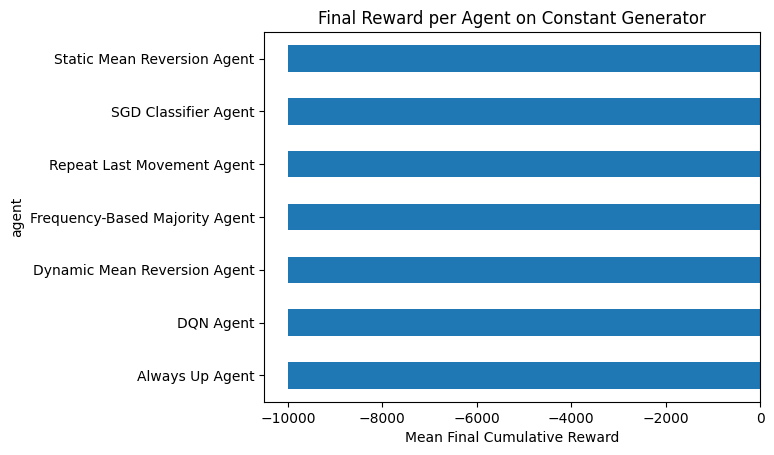

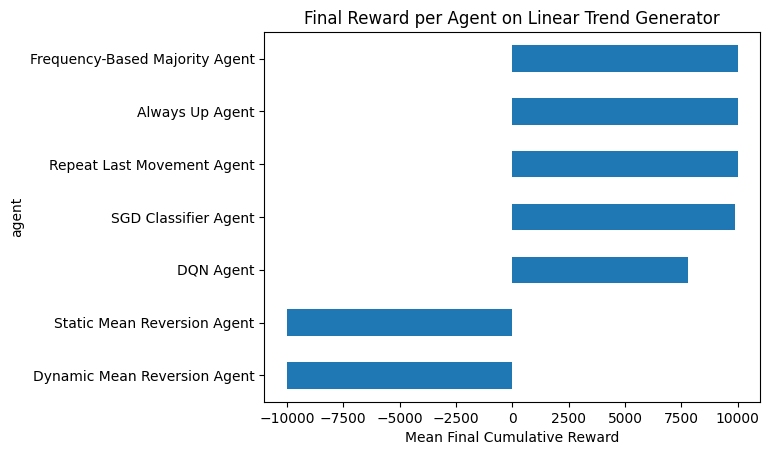

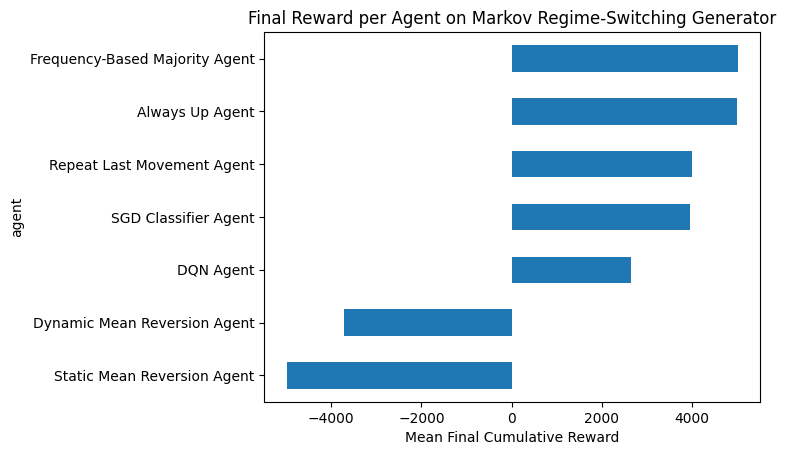

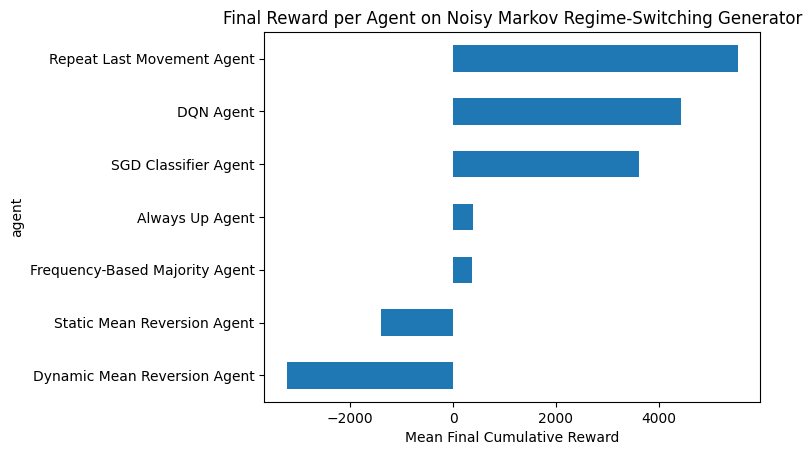

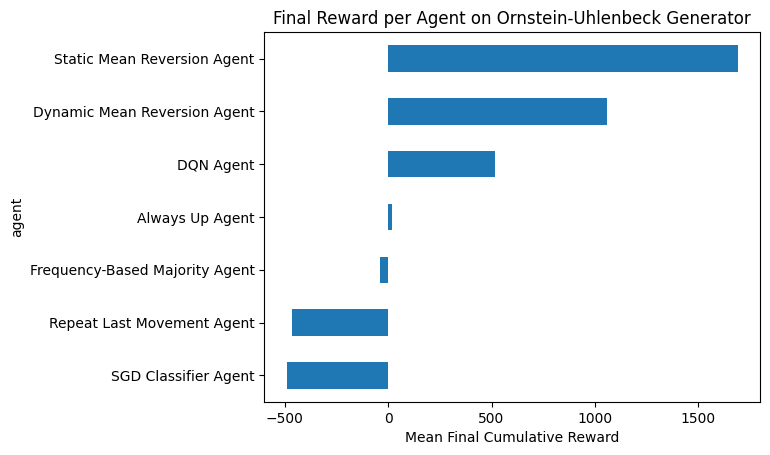

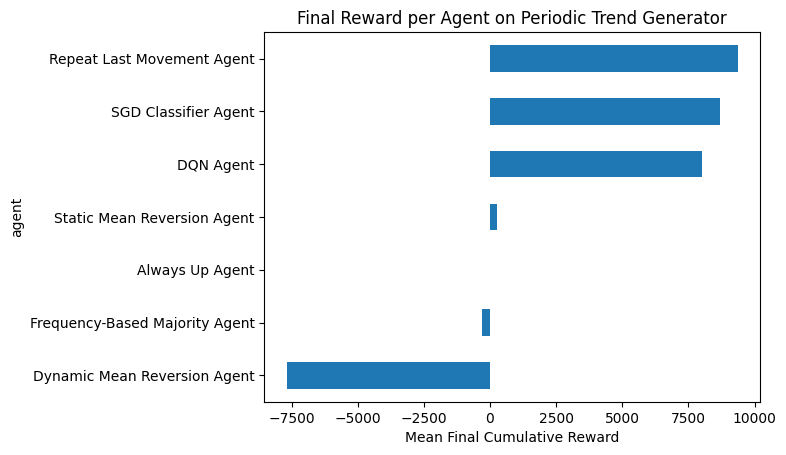

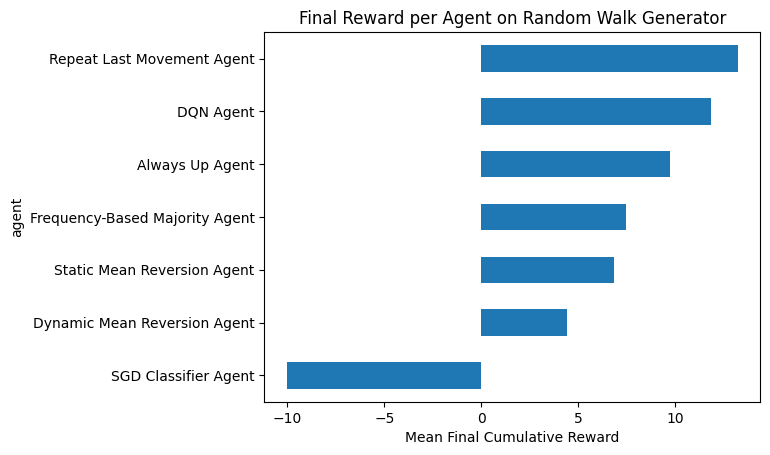

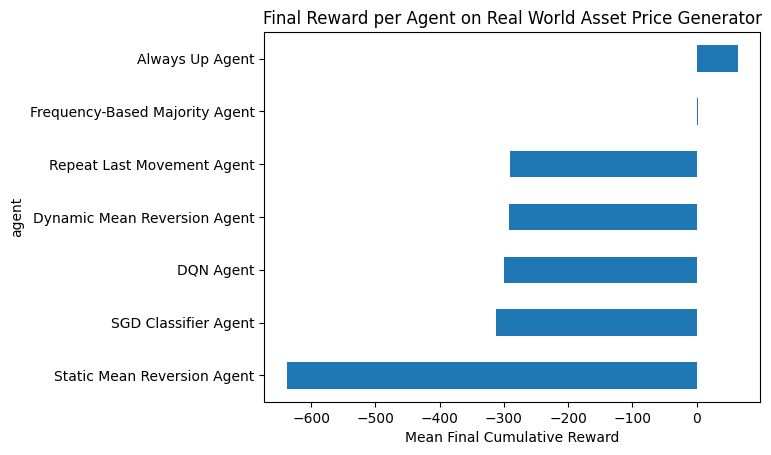

In [62]:

for generator in df["generator"].unique():
    subset = df[df["generator"] == generator]
    plt.figure()
    subset.groupby("agent")["final_cumulative_reward"].mean().sort_values().plot(kind="barh")
    plt.title(f"Final Reward per Agent on {generator}")
    plt.xlabel("Mean Final Cumulative Reward")
    plt.show()


# 3 Reward Distribution per Agent and Generator

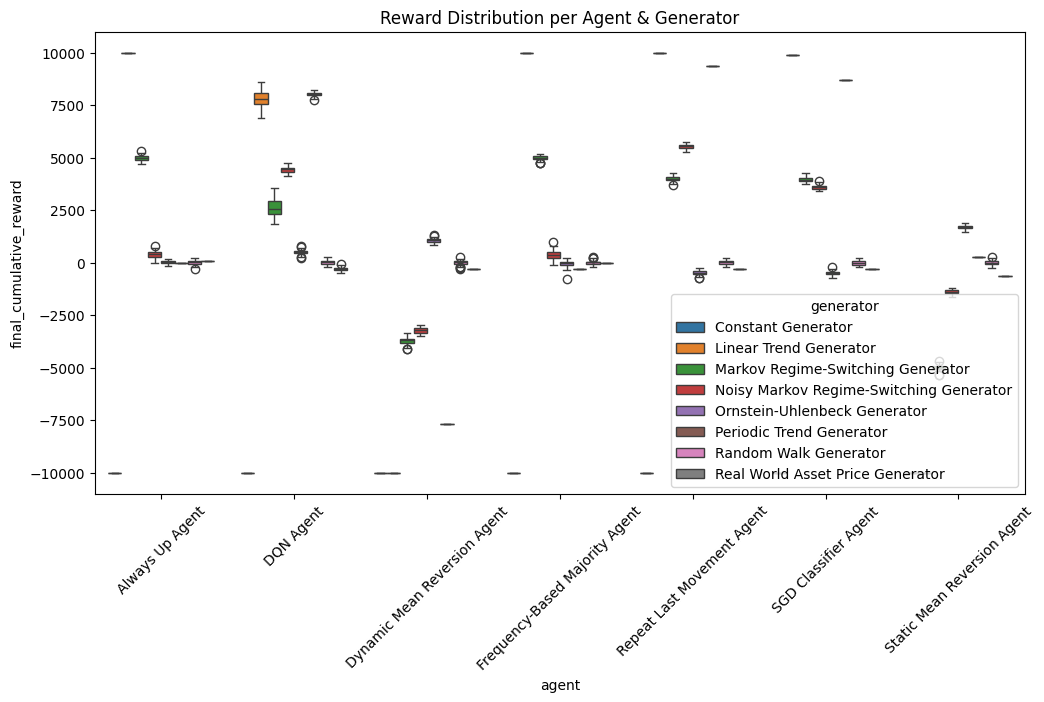

In [63]:

plt.figure(figsize=(12, 6))
sns.boxplot(x="agent", y="final_cumulative_reward", hue="generator", data=df)
plt.xticks(rotation=45)
plt.title("Reward Distribution per Agent & Generator")
plt.show()


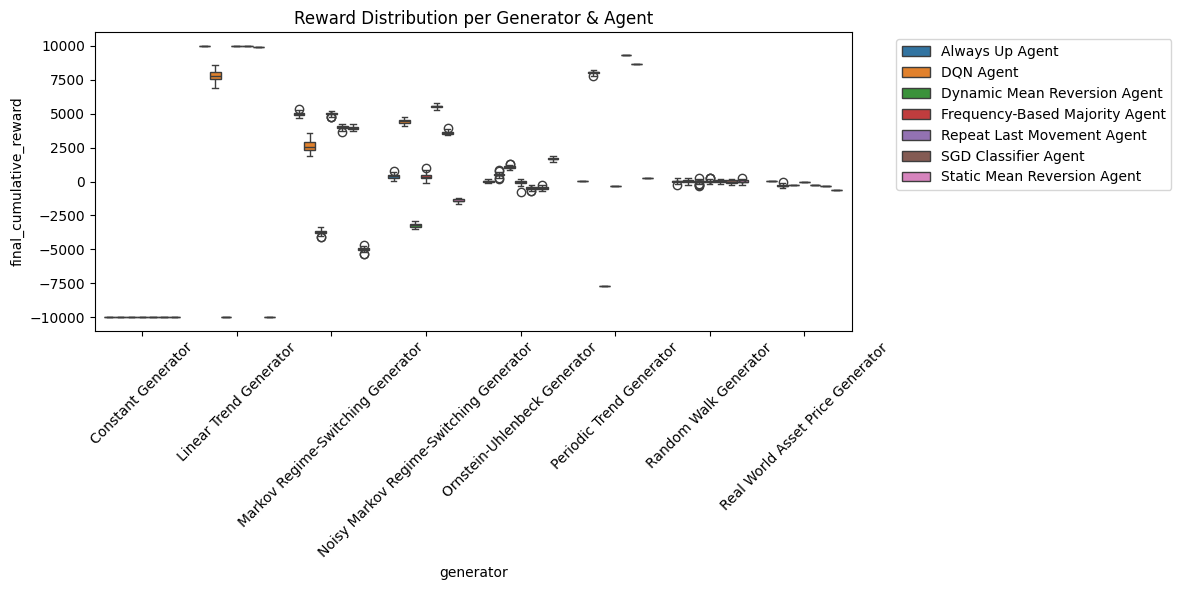

In [64]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="generator", y="final_cumulative_reward", hue="agent", data=df)
plt.xticks(rotation=45)
plt.title("Reward Distribution per Generator & Agent")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

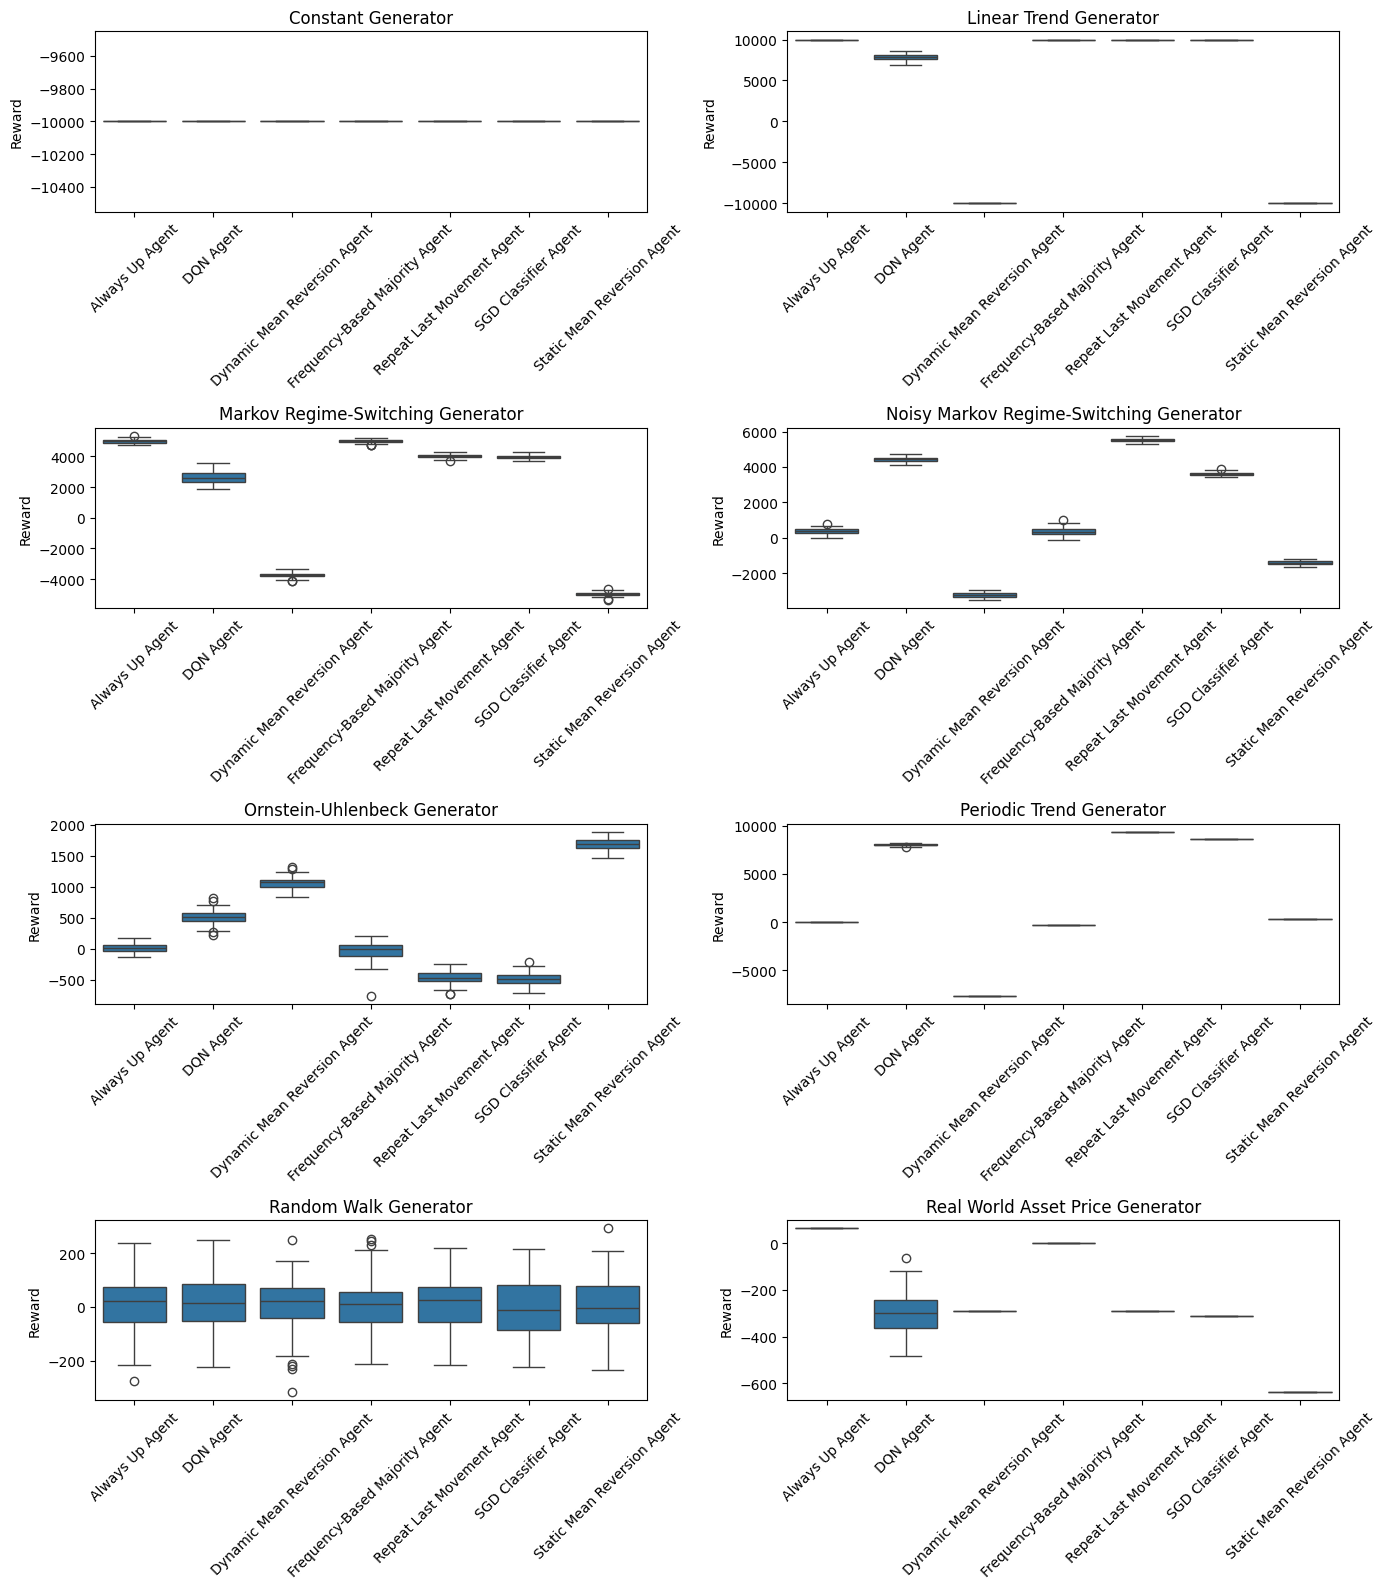

In [75]:

# Make sure your DataFrame `df` has the following columns:
# - 'generator' (e.g., "Linear Trend Generator")
# - 'agent' (e.g., "DQN Agent")
# - 'final_cumulative_reward' (numeric values)

# List of unique generators
generators = df['generator'].unique()

# Create 2x4 subplots
fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharey=False)
axes = axes.flatten()

# Plot for each generator
for i, gen in enumerate(generators):
    ax = axes[i]
    sns.boxplot(x='agent', y='final_cumulative_reward', data=df[df['generator'] == gen], ax=ax)
    ax.set_title(gen)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('Reward')

# Hide unused subplot if generators < 8
for j in range(len(generators), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


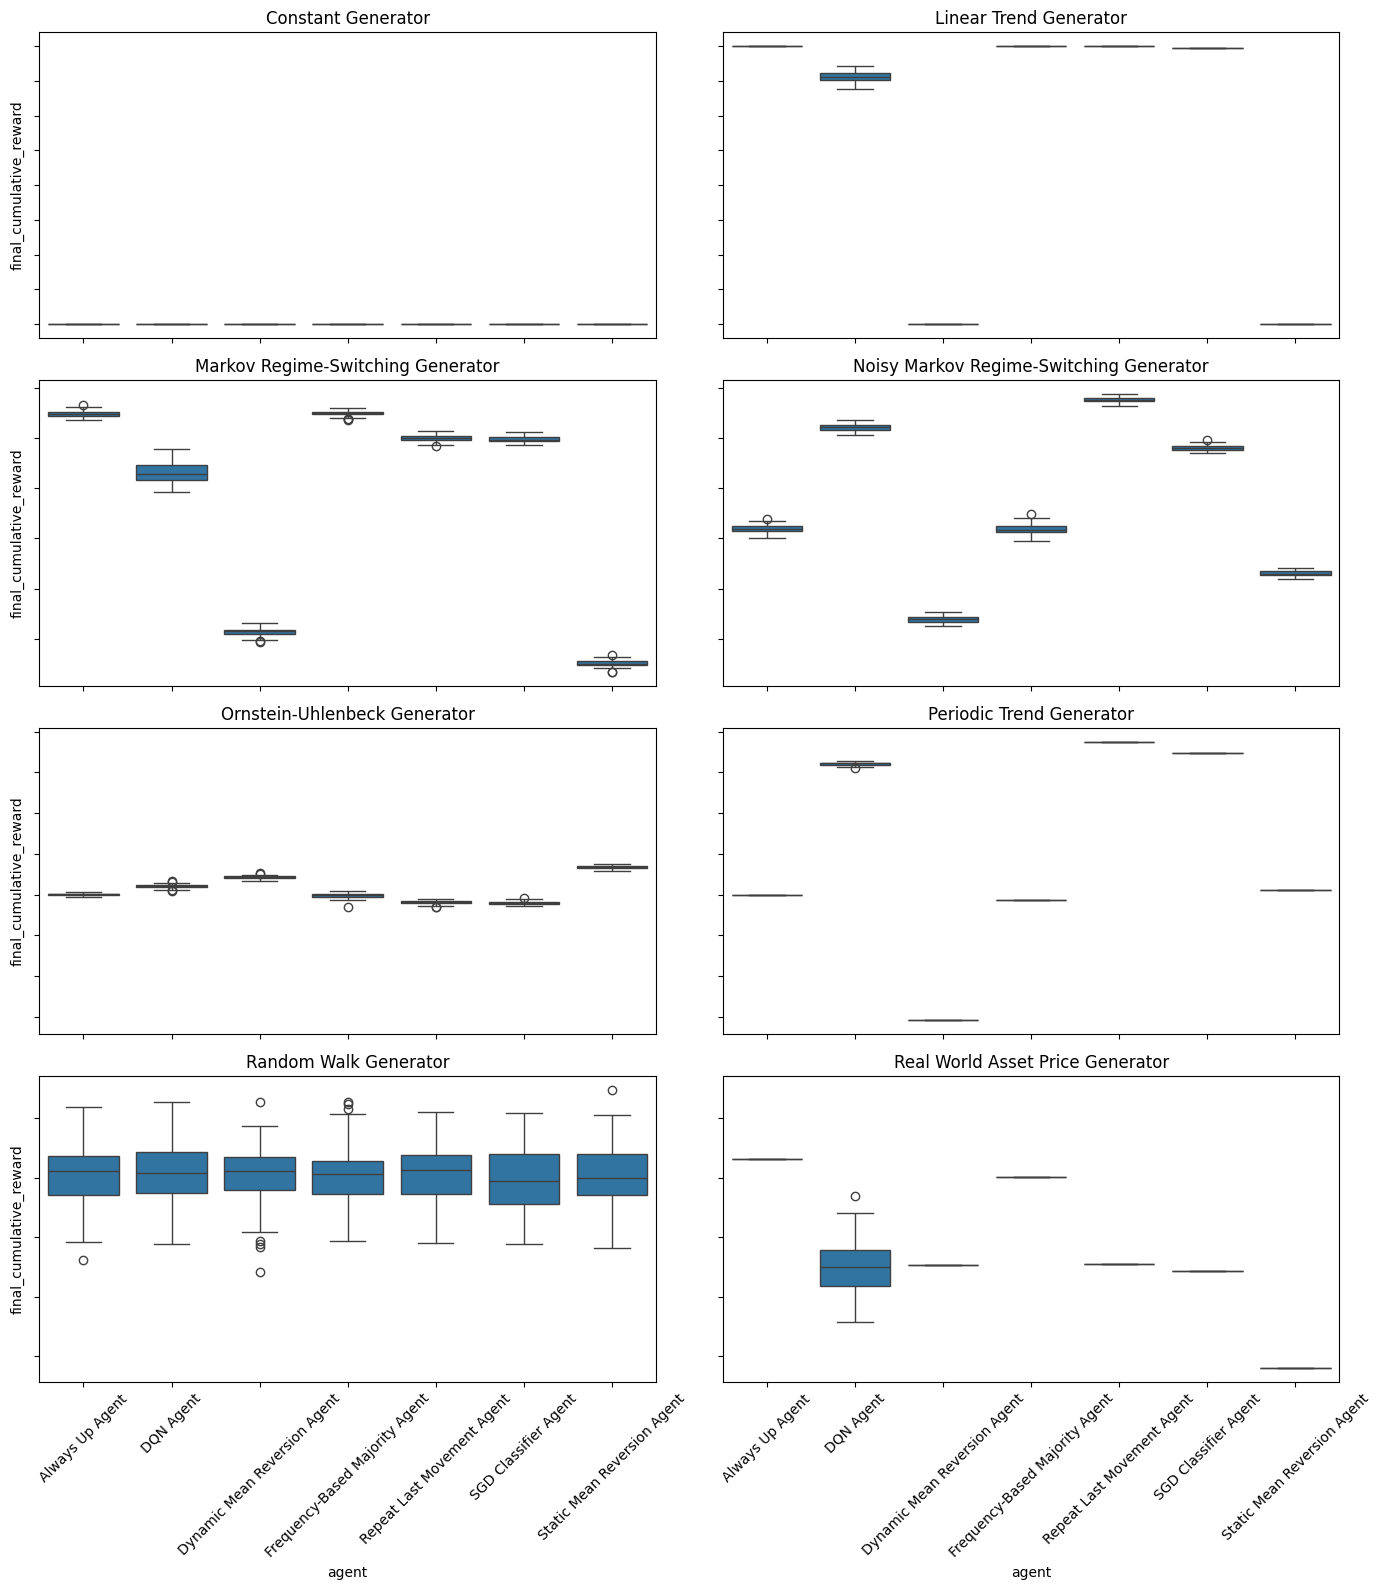

In [77]:
# List of unique generators (in desired order, optional)
generators = df['generator'].unique()

# Set up subplot grid: 4 rows × 2 columns
fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharey='row')
axes = axes.flatten()

for i, gen in enumerate(generators):
    ax = axes[i]
    data = df[df['generator'] == gen]
    
    sns.boxplot(x='agent', y='final_cumulative_reward', data=data, ax=ax)
    ax.set_title(gen)
    ax.tick_params(axis='x', rotation=45)
    
    # Only show x-labels on bottom row
    if i < 6:
        ax.set_xlabel('')
        ax.set_xticklabels([])
    
    # Only show y-label on left column
    if i % 2 == 1:
        ax.set_ylabel('Reward')
        ax.set_yticklabels([])

# Hide unused subplots if fewer than 8
for j in range(len(generators), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

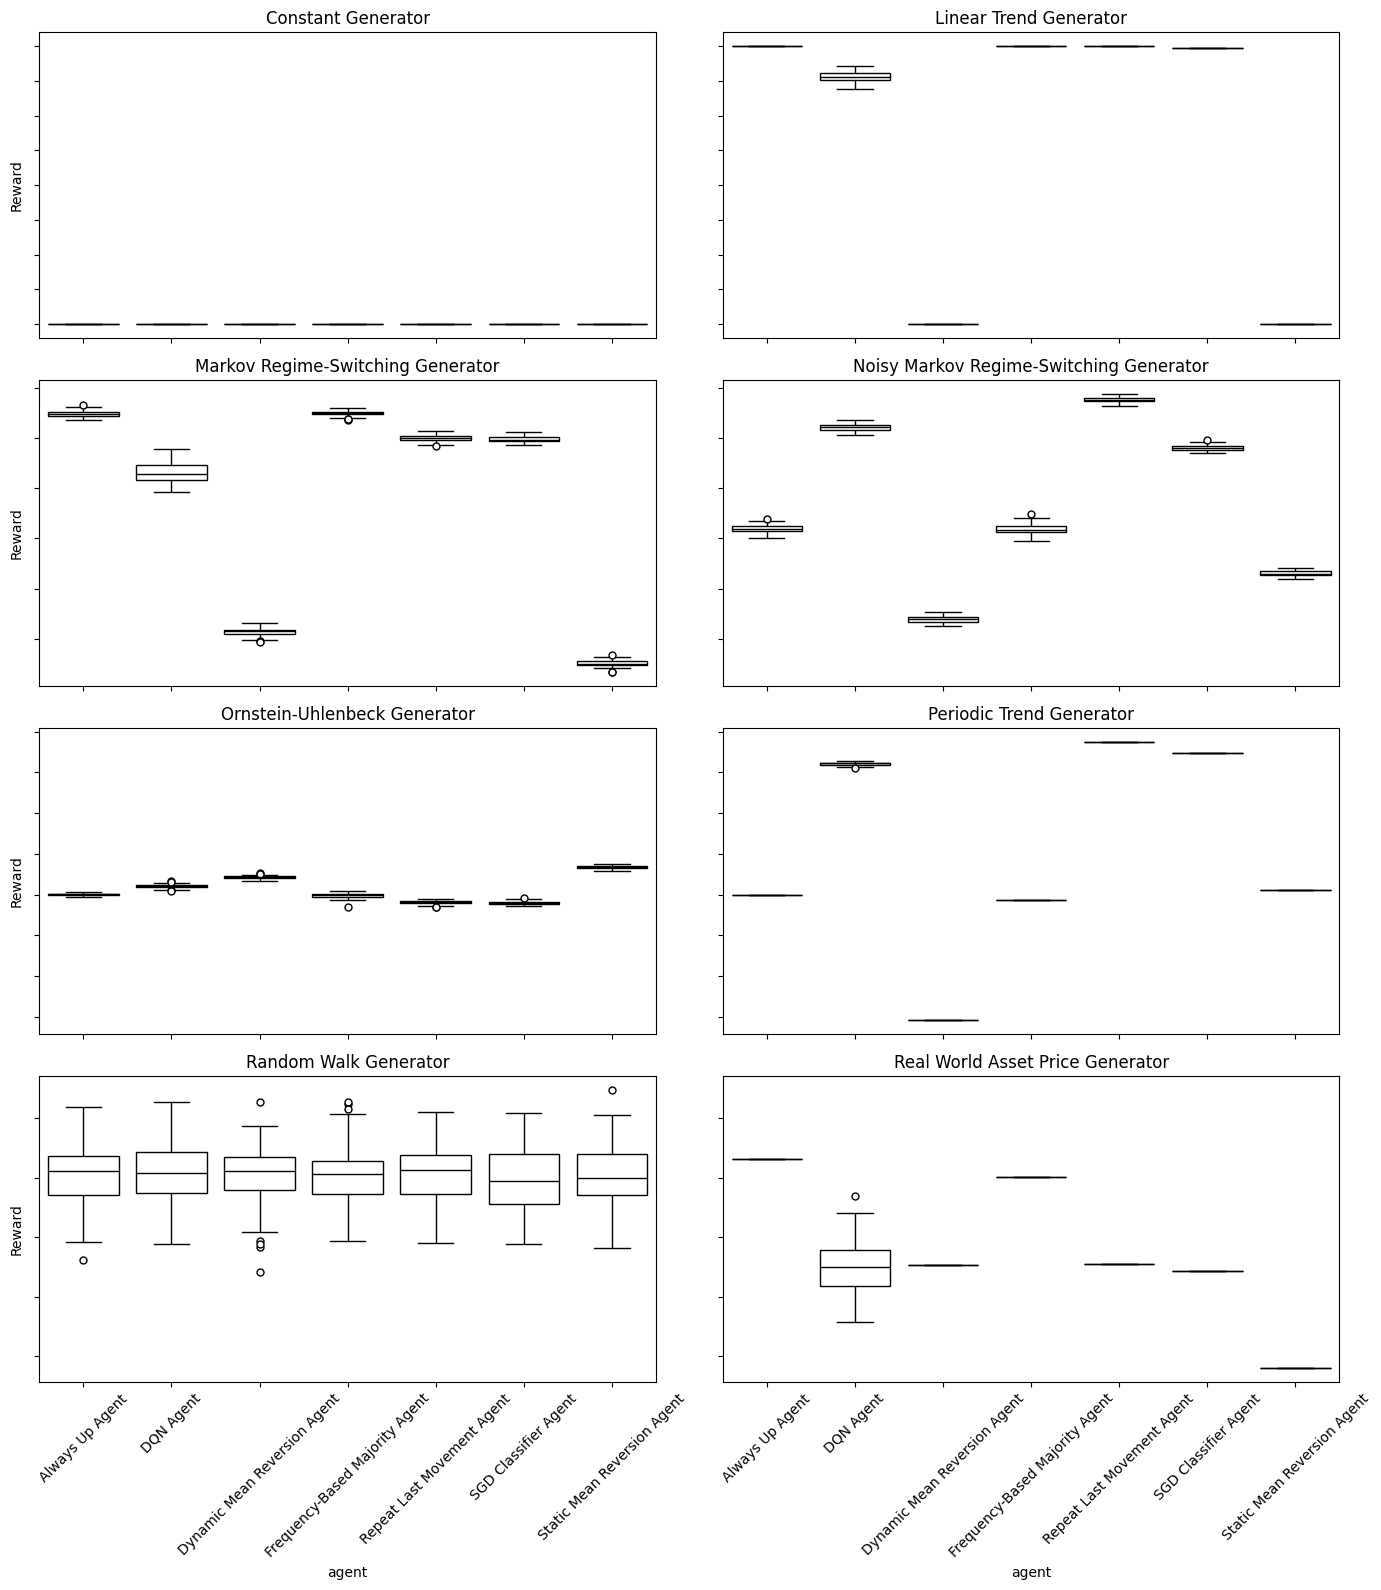

In [78]:
# Unique generators
generators = df['generator'].unique()

# Create 4x2 subplot grid
fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharey='row')
axes = axes.flatten()

# Use black-and-white styling
box_kws = {
    'boxprops': dict(facecolor='white', edgecolor='black'),
    'medianprops': dict(color='black'),
    'whiskerprops': dict(color='black'),
    'capprops': dict(color='black'),
    'flierprops': dict(marker='o', markerfacecolor='white', markeredgecolor='black', markersize=5)
}

for i, gen in enumerate(generators):
    ax = axes[i]
    data = df[df['generator'] == gen]
    
    sns.boxplot(
        x='agent',
        y='final_cumulative_reward',
        data=data,
        ax=ax,
        **box_kws
    )
    
    ax.set_title(gen)
    ax.tick_params(axis='x', rotation=45)

    # Show x-axis labels only on bottom row
    if i < 6:
        ax.set_xlabel('')
        ax.set_xticklabels([])

    # Show y-axis label only on left column
    if i % 2 == 0:
        ax.set_ylabel('Reward')
    else:
        ax.set_ylabel('')
        ax.set_yticklabels([])

# Hide any unused subplots
for j in range(len(generators), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

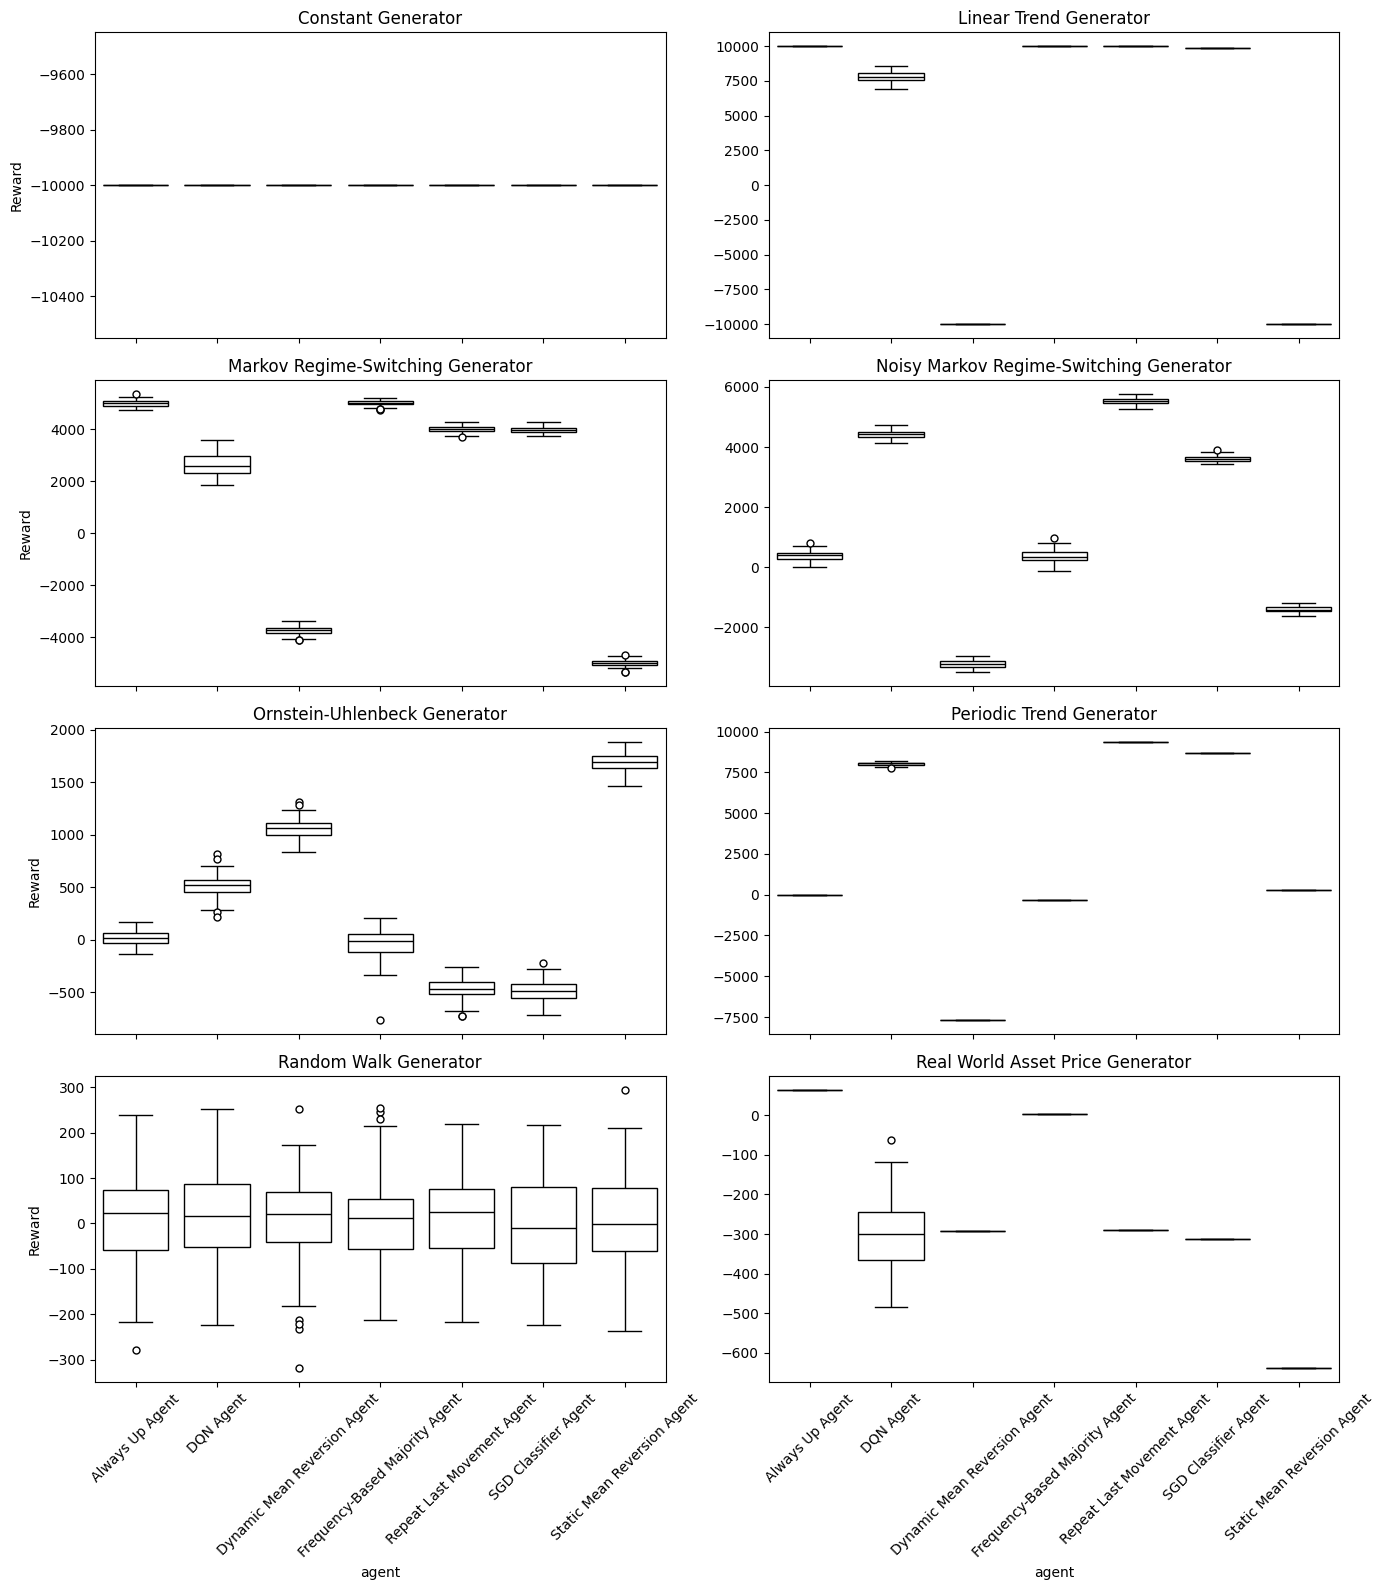

In [79]:
# Unique generators
generators = df['generator'].unique()

# Create 4x2 subplot grid without shared y-axis
fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharey=False)
axes = axes.flatten()

# Black-and-white boxplot styling
box_kws = {
    'boxprops': dict(facecolor='white', edgecolor='black'),
    'medianprops': dict(color='black'),
    'whiskerprops': dict(color='black'),
    'capprops': dict(color='black'),
    'flierprops': dict(marker='o', markerfacecolor='white', markeredgecolor='black', markersize=5)
}

for i, gen in enumerate(generators):
    ax = axes[i]
    data = df[df['generator'] == gen]

    sns.boxplot(
        x='agent',
        y='final_cumulative_reward',
        data=data,
        ax=ax,
        **box_kws
    )
    
    ax.set_title(gen)
    ax.tick_params(axis='x', rotation=45)

    # Show x-axis labels only on bottom row
    if i < 6:
        ax.set_xlabel('')
        ax.set_xticklabels([])

    # Add y-axis label only to left column
    if i % 2 == 0:
        ax.set_ylabel('Reward')
    else:
        ax.set_ylabel('')  # keep ticks visible

# Hide any unused subplots
for j in range(len(generators), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# 4 Heat Map of Agent-Generator Combinations

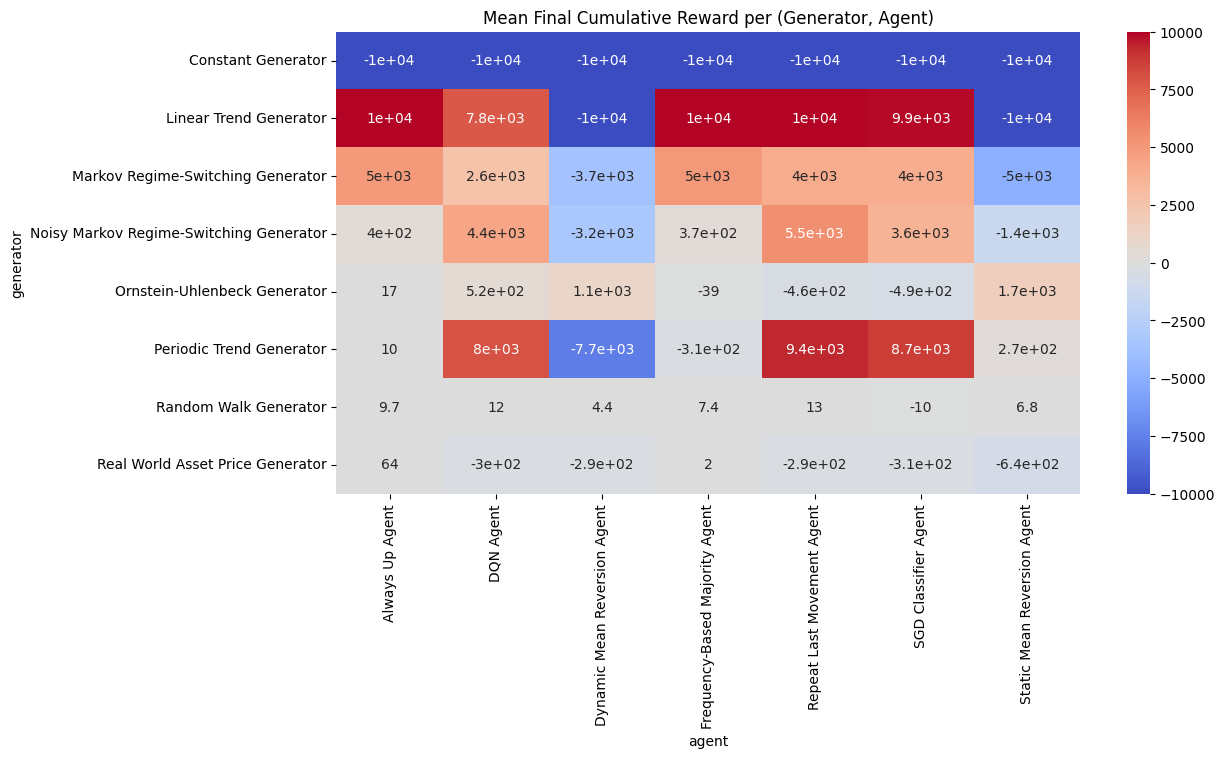

In [65]:
pivot_table = df.pivot_table(
    index="generator",
    columns="agent",
    values="final_cumulative_reward",
    aggfunc="mean"
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, annot=True, cmap="coolwarm", center=0)
plt.title("Mean Final Cumulative Reward per (Generator, Agent)")
plt.show()


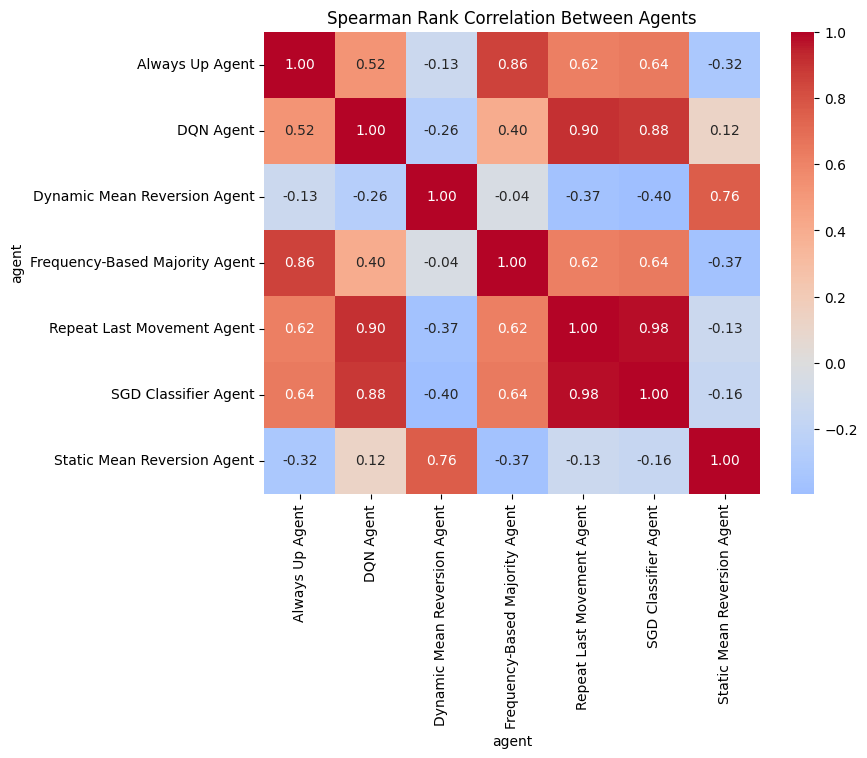

In [66]:
# Transpose so agents are rows, generators are columns
pivot_transposed = pivot_table.T

# Calculate Spearman correlation between agents
corr_matrix, p_values = spearmanr(pivot_transposed, axis=1)

# Convert to DataFrame for readability
agent_names = pivot_transposed.index
corr_df = pd.DataFrame(corr_matrix, index=agent_names, columns=agent_names)


plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Spearman Rank Correlation Between Agents")
plt.show();

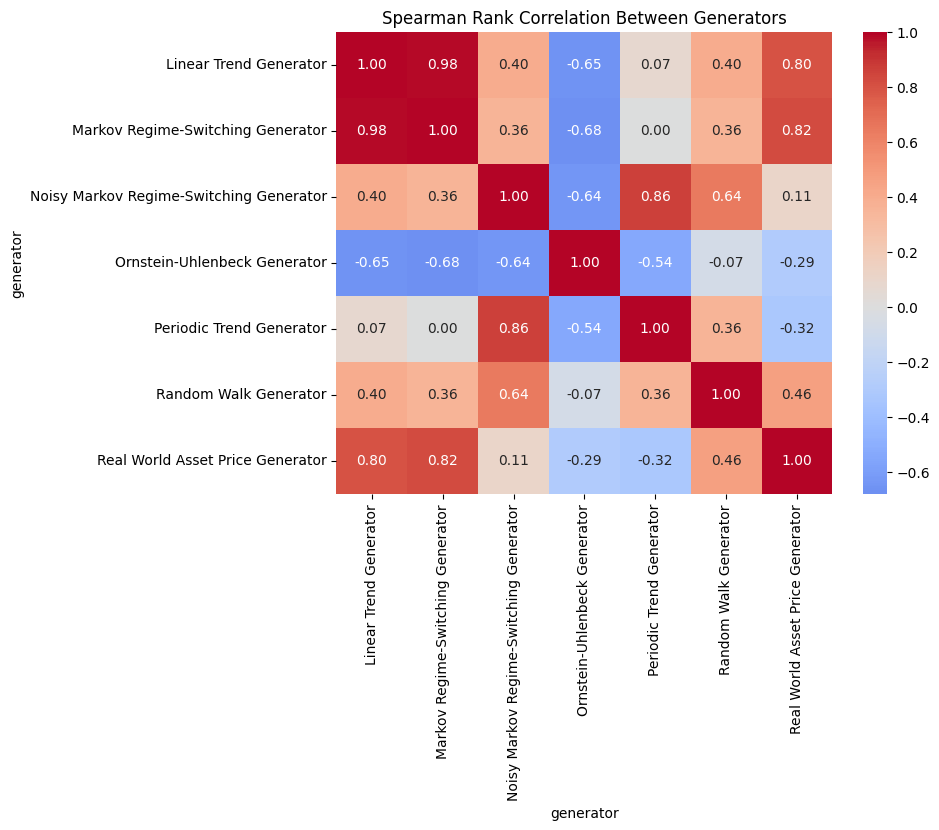

In [67]:
# Filter out constant rows before correlation
non_constant_rows = pivot_table.loc[pivot_table.var(axis=1) > 0]
corr_matrix_gens, _ = spearmanr(non_constant_rows, axis=1)
corr_df_gens = pd.DataFrame(corr_matrix_gens, index=non_constant_rows.index, columns=non_constant_rows.index)

# Plot only if matrix is non-empty
if not corr_df_gens.empty:
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_df_gens, annot=True, cmap="coolwarm", center=0, fmt=".2f")
    plt.title("Spearman Rank Correlation Between Generators")
    plt.show()
else:
    print("No variable generators for correlation analysis.")


In [68]:
agent_generator_table = pivot_table.T.copy()
agent_generator_table["Mean Across Generators"] = agent_generator_table.mean(axis=1)
agent_generator_table

generator,Constant Generator,Linear Trend Generator,Markov Regime-Switching Generator,Noisy Markov Regime-Switching Generator,Ornstein-Uhlenbeck Generator,Periodic Trend Generator,Random Walk Generator,Real World Asset Price Generator,Mean Across Generators
agent,,,,,,,,,
Always Up Agent,-10000.0,10000.00,4989.50,396.64,17.00,10.00,9.74,64.00,685.8600
DQN Agent,-10000.0,7795.24,2634.60,4433.92,516.28,8028.42,11.86,-300.54,1639.9725
Dynamic Mean Reversion Agent,-10000.0,-10000.00,-3723.46,-3229.84,1060.42,-7678.00,4.40,-292.00,-4232.3100
Frequency-Based Majority Agent,-10000.0,10000.00,5006.74,371.78,-38.88,-308.00,7.44,2.00,630.1350
Repeat Last Movement Agent,-10000.0,9998.00,4000.66,5533.74,-463.54,9362.00,13.22,-290.00,2269.2600
SGD Classifier Agent,-10000.0,9900.00,3959.10,3614.10,-490.86,8684.00,-10.02,-312.00,1918.0400
Static Mean Reversion Agent,-10000.0,-10000.00,-4980.96,-1395.90,1691.98,270.00,6.82,-638.00,-3130.7575


In [72]:
# drop last column (mean across generators) for ranking
agent_generator_table = agent_generator_table.iloc[:,:-1]

# Compute rank table: higher reward = better = lower rank (rank 1 = best)
agent_rank_df = agent_generator_table.rank(ascending=False, method='average')

# Calculate mean rank per agent
agent_rank_df["Mean Rank"] = agent_rank_df.mean(axis=1)

# Add column for range of ranks across given row
agent_rank_df["Rank Range"] = agent_rank_df.max(axis=1) - agent_rank_df.min(axis=1)


# sort by mean rank

agent_rank_df = agent_rank_df.sort_values(by="Mean Rank").round(2)

# Display the rank table
agent_rank_df

generator,Constant Generator,Linear Trend Generator,Markov Regime-Switching Generator,Noisy Markov Regime-Switching Generator,Ornstein-Uhlenbeck Generator,Periodic Trend Generator,Mean Rank,Rank Range
agent,,,,,,,,
Repeat Last Movement Agent,4.0,3.0,3.0,1.0,6.0,1.0,3.00,5.0
Always Up Agent,4.0,1.5,2.0,4.0,4.0,5.0,3.42,3.5
DQN Agent,4.0,5.0,5.0,2.0,3.0,3.0,3.67,3.0
Frequency-Based Majority Agent,4.0,1.5,1.0,5.0,5.0,6.0,3.75,5.0
SGD Classifier Agent,4.0,4.0,4.0,3.0,7.0,2.0,4.00,5.0
Static Mean Reversion Agent,4.0,6.5,7.0,6.0,1.0,4.0,4.75,6.0
Dynamic Mean Reversion Agent,4.0,6.5,6.0,7.0,2.0,7.0,5.42,5.0


In [74]:
# Compute rank table: higher reward = better = lower rank (rank 1 = best)
gen_rank_df = agent_generator_table.rank(axis=1, ascending=False, method='average')

# transpose so agents are rows, generators are columns
gen_rank_df = gen_rank_df.T

# Calculate mean rank per agent
gen_rank_df["Mean Rank"] = gen_rank_df.mean(axis=1)

# Add column for range of ranks across given row
gen_rank_df["Rank Range"] = gen_rank_df.max(axis=1) - gen_rank_df.min(axis=1)


# sort by mean rank

gen_rank_df = gen_rank_df.sort_values(by="Mean Rank").round(2)

# Display the rank table
gen_rank_df

agent,Always Up Agent,DQN Agent,Dynamic Mean Reversion Agent,Frequency-Based Majority Agent,Repeat Last Movement Agent,SGD Classifier Agent,Static Mean Reversion Agent,Mean Rank,Rank Range
generator,,,,,,,,,
Linear Trend Generator,1.0,2.0,5.5,1.0,1.0,1.0,5.5,2.43,4.5
Noisy Markov Regime-Switching Generator,3.0,3.0,2.0,3.0,3.0,4.0,3.0,3.00,2.0
Periodic Trend Generator,5.0,1.0,4.0,5.0,2.0,2.0,2.0,3.00,4.0
Markov Regime-Switching Generator,2.0,4.0,3.0,2.0,4.0,3.0,4.0,3.14,2.0
Ornstein-Uhlenbeck Generator,4.0,5.0,1.0,4.0,5.0,5.0,1.0,3.57,4.0
Constant Generator,6.0,6.0,5.5,6.0,6.0,6.0,5.5,5.86,0.5


# 4 Statistical Significance Testing

In [ ]:
df

,agent,generator,run_id,total_steps,start_value,final_cumulative_reward,average_reward
0,Always Up Agent,Constant Generator,1,10000,0.0,-10000,-1.0000
1,Always Up Agent,Constant Generator,2,10000,0.0,-10000,-1.0000
2,Always Up Agent,Constant Generator,3,10000,0.0,-10000,-1.0000
3,Always Up Agent,Constant Generator,4,10000,0.0,-10000,-1.0000
4,Always Up Agent,Constant Generator,5,10000,0.0,-10000,-1.0000
...,...,...,...,...,...,...,...
5595,Static Mean Reversion Agent,Real World Asset Price Generator,96,10000,0.0,-638,-0.0638
5596,Static Mean Reversion Agent,Real World Asset Price Generator,97,10000,0.0,-638,-0.0638
5597,Static Mean Reversion Agent,Real World Asset Price Generator,98,10000,0.0,-638,-0.0638
5598,Static Mean Reversion Agent,Real World Asset Price Generator,99,10000,0.0,-638,-0.0638


In [ ]:
def compute_ci(data, confidence=0.95):
    mean = data.mean()
    sem = st.sem(data)
    ci_range = sem * st.t.ppf((1 + confidence) / 2., len(data) - 1)
    return pd.Series({'mean': mean, 'ci_lower': mean - ci_range, 'ci_upper': mean + ci_range})

# Apply groupby and expand into columns
ci_df = df.groupby(["agent", "generator"])["final_cumulative_reward"].apply(compute_ci).reset_index()


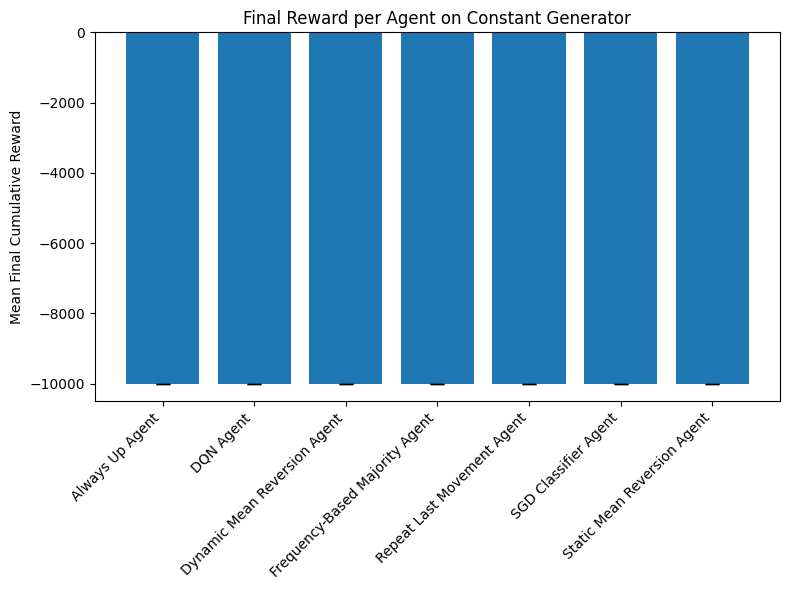

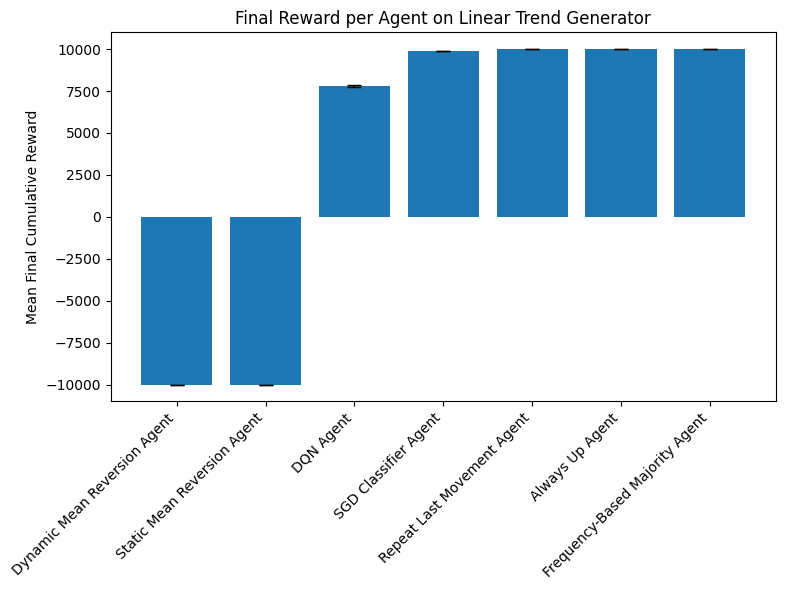

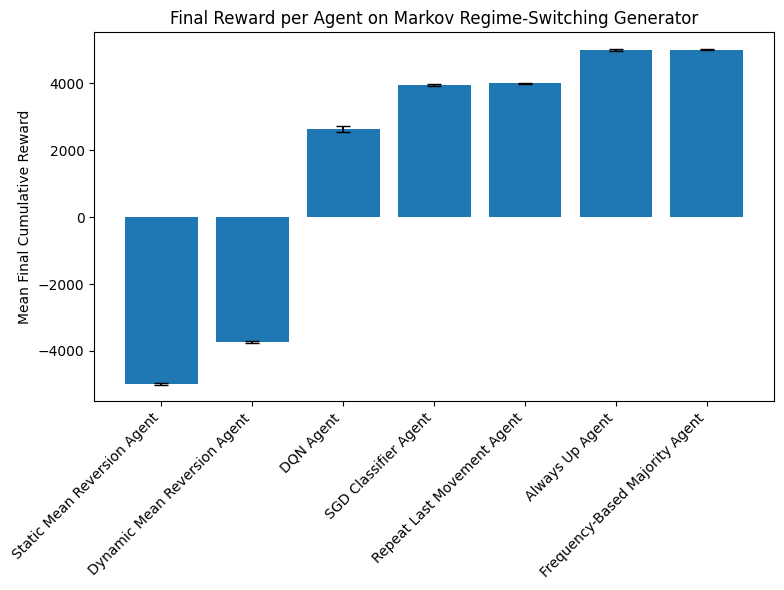

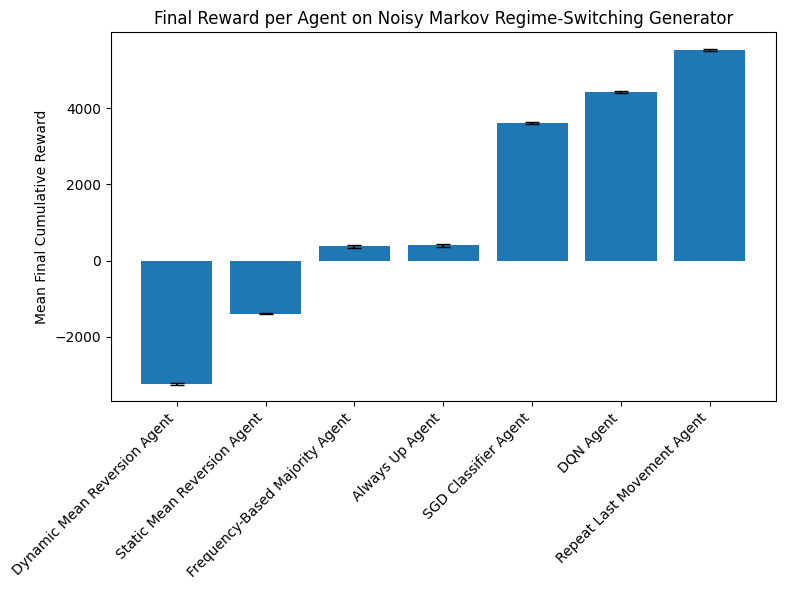

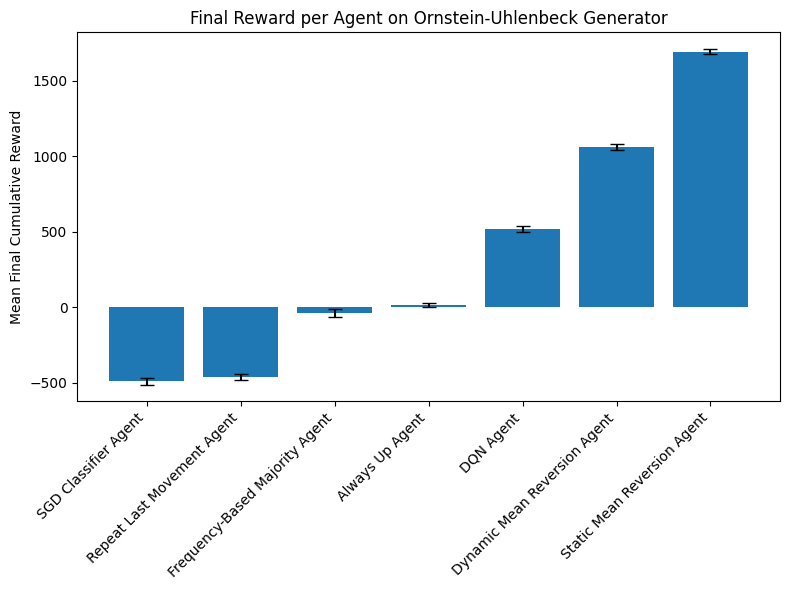

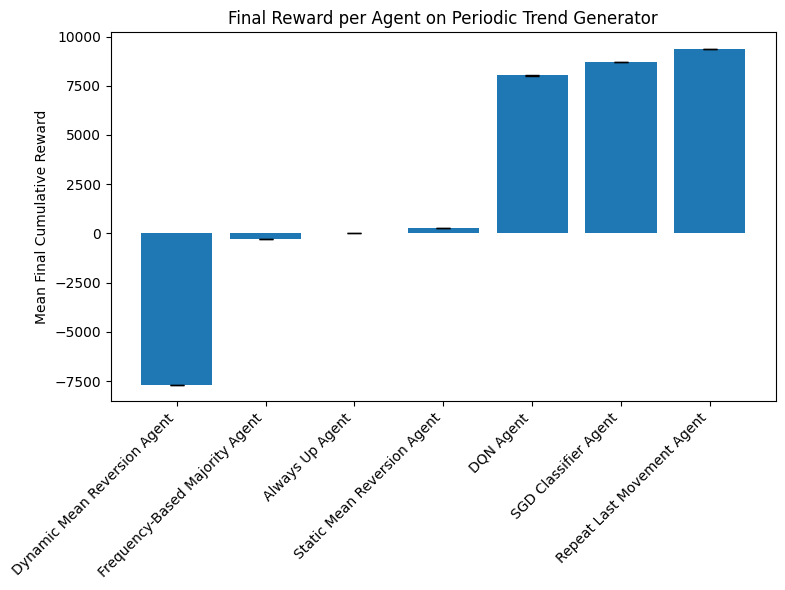

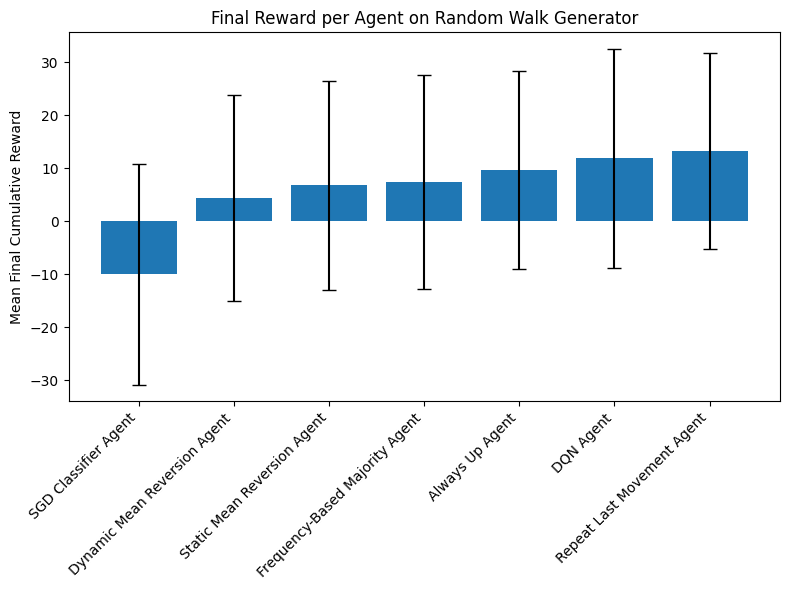

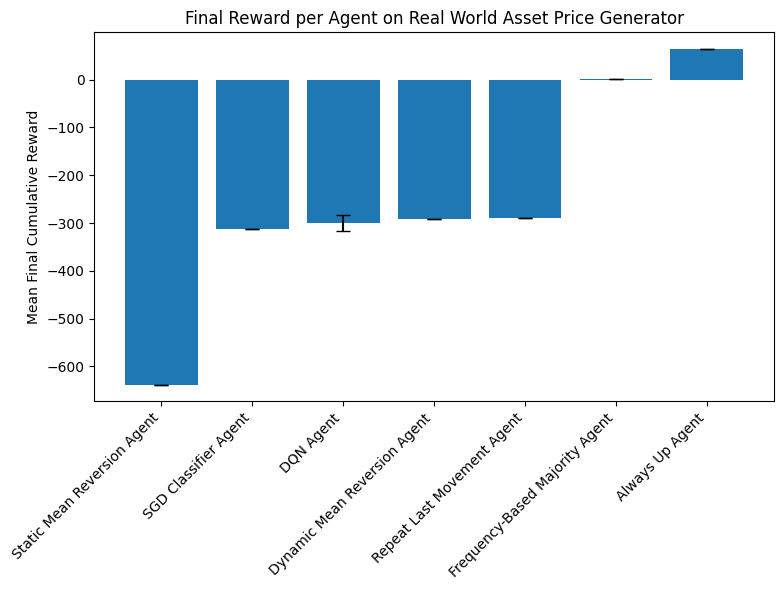

In [ ]:
for generator in df["generator"].unique():
    subset_ci = ci_df[ci_df["generator"] == generator].pivot(index="agent", columns="level_2", values="final_cumulative_reward").reset_index()
    subset_ci_sorted = subset_ci.sort_values("mean")
    
    plt.figure(figsize=(8, 6))
    plt.bar(subset_ci_sorted["agent"], subset_ci_sorted["mean"], 
            yerr=[subset_ci_sorted["mean"] - subset_ci_sorted["ci_lower"], 
                  subset_ci_sorted["ci_upper"] - subset_ci_sorted["mean"]],
            capsize=5)
    plt.title(f"Final Reward per Agent on {generator}")
    plt.ylabel("Mean Final Cumulative Reward")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


In [ ]:
from scipy.stats import kruskal

for generator in df["generator"].unique():
    subset = df[df["generator"] == generator]
    groups = [group["final_cumulative_reward"].values for _, group in subset.groupby("agent")]
    
    # Check if all groups have constant identical values
    if all(len(set(g)) == 1 for g in groups):
        print(f"{generator}: Skipped (all groups identical)")
        continue
    
    stat, p = kruskal(*groups)
    print(f"{generator}: Kruskal-Wallis H = {stat:.2f}, p = {p:.4f}")


Constant Generator: Skipped (all groups identical)
Linear Trend Generator: Kruskal-Wallis H = 696.85, p = 0.0000
Markov Regime-Switching Generator: Kruskal-Wallis H = 660.95, p = 0.0000
Noisy Markov Regime-Switching Generator: Kruskal-Wallis H = 672.59, p = 0.0000
Ornstein-Uhlenbeck Generator: Kruskal-Wallis H = 659.27, p = 0.0000
Periodic Trend Generator: Kruskal-Wallis H = 696.93, p = 0.0000
Random Walk Generator: Kruskal-Wallis H = 3.96, p = 0.6820
Real World Asset Price Generator: Kruskal-Wallis H = 628.30, p = 0.0000


c:\Users\JanderM\AppData\Local\anaconda3\envs\pred-bet-game\lib\site-packages\scikit_posthocs\_posthocs.py:366: RuntimeWarning: invalid value encountered in scalar divide
  z_value = diff / np.sqrt((A - x_ties) * B)
C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_discrete = dunn.applymap(discretize_pval_num)
C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:42: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_labels = dunn.applymap(discretize_pval_label)


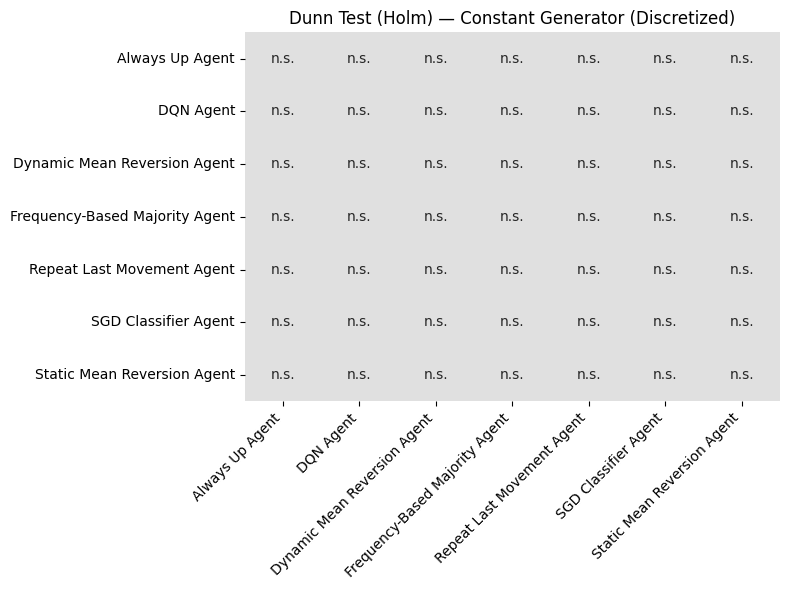

C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_discrete = dunn.applymap(discretize_pval_num)
C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:42: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_labels = dunn.applymap(discretize_pval_label)


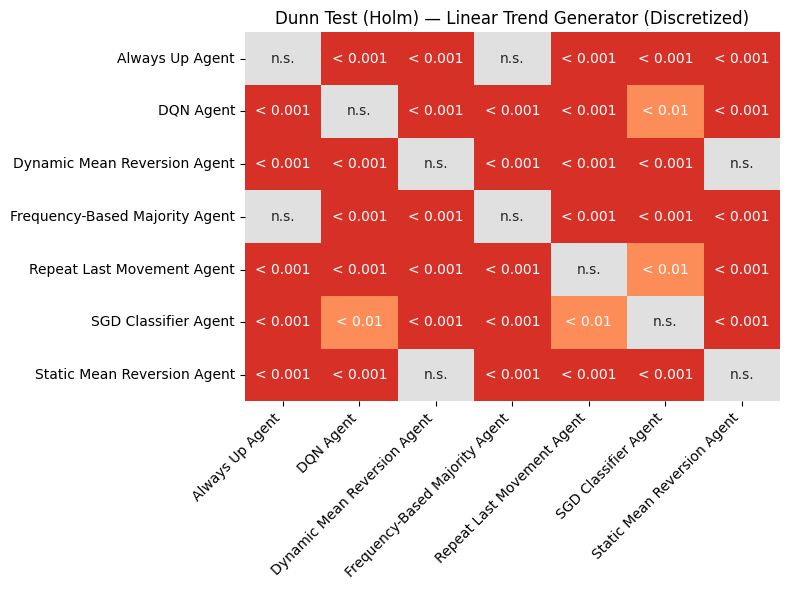

C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_discrete = dunn.applymap(discretize_pval_num)
C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:42: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_labels = dunn.applymap(discretize_pval_label)


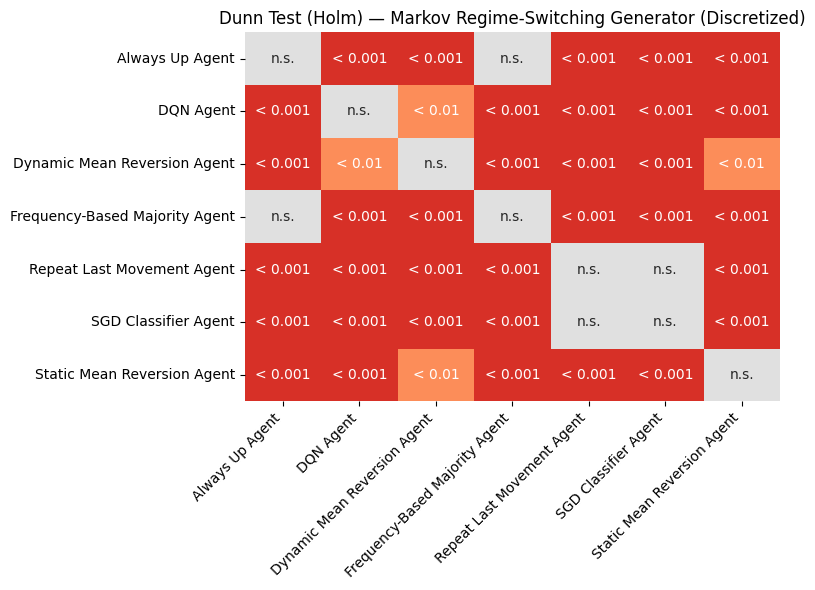

C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_discrete = dunn.applymap(discretize_pval_num)
C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:42: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_labels = dunn.applymap(discretize_pval_label)


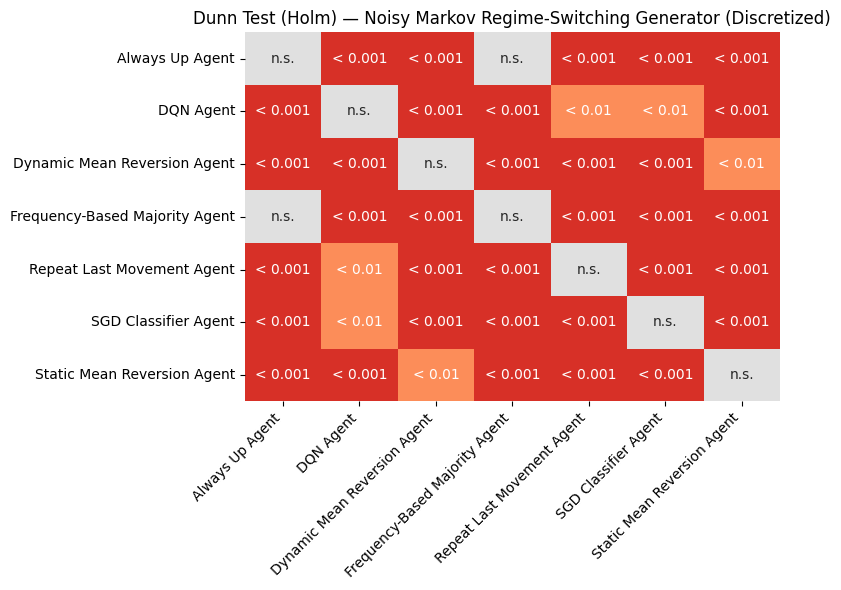

C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_discrete = dunn.applymap(discretize_pval_num)
C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:42: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_labels = dunn.applymap(discretize_pval_label)


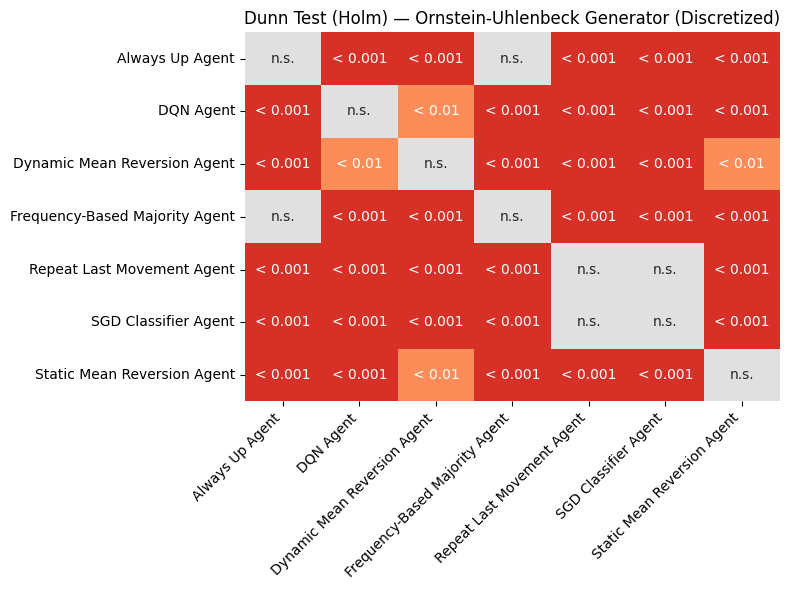

C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_discrete = dunn.applymap(discretize_pval_num)
C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:42: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_labels = dunn.applymap(discretize_pval_label)


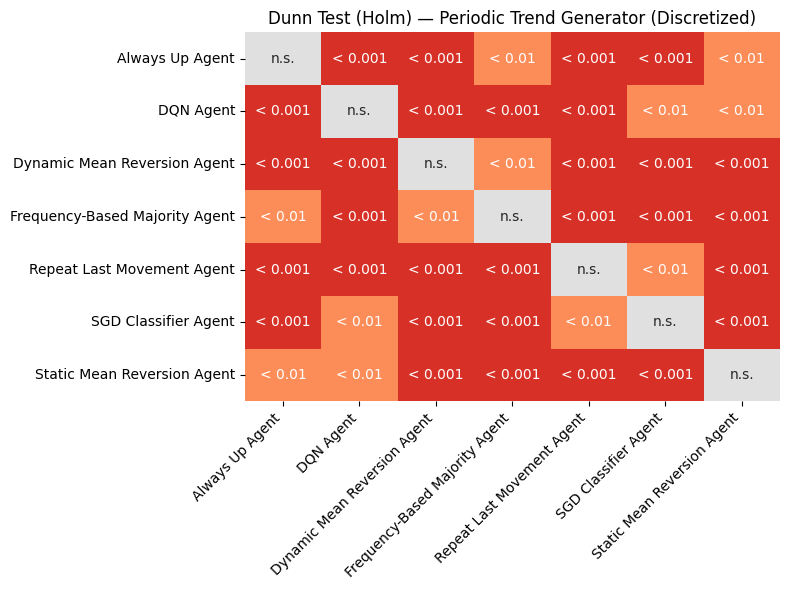

C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_discrete = dunn.applymap(discretize_pval_num)
C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:42: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_labels = dunn.applymap(discretize_pval_label)


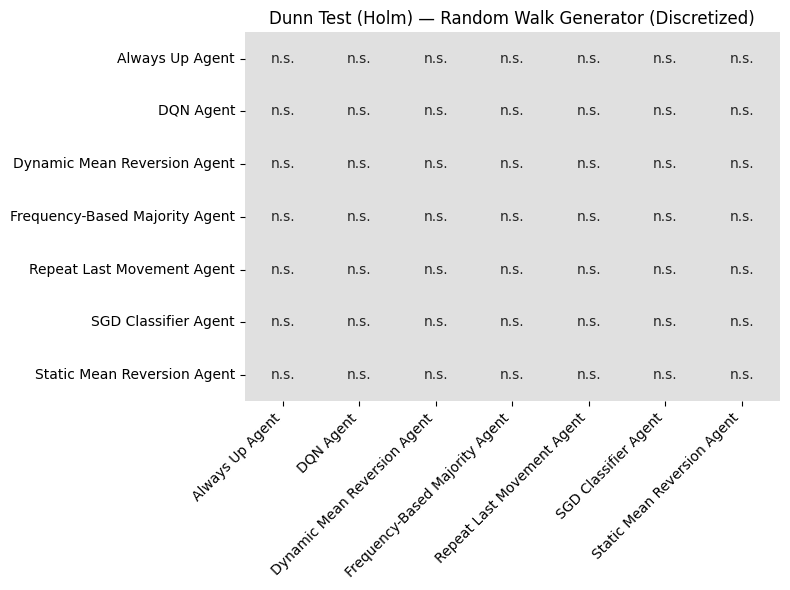

C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_discrete = dunn.applymap(discretize_pval_num)
C:\Users\JanderM\AppData\Local\Temp\ipykernel_16056\4083178155.py:42: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dunn_labels = dunn.applymap(discretize_pval_label)


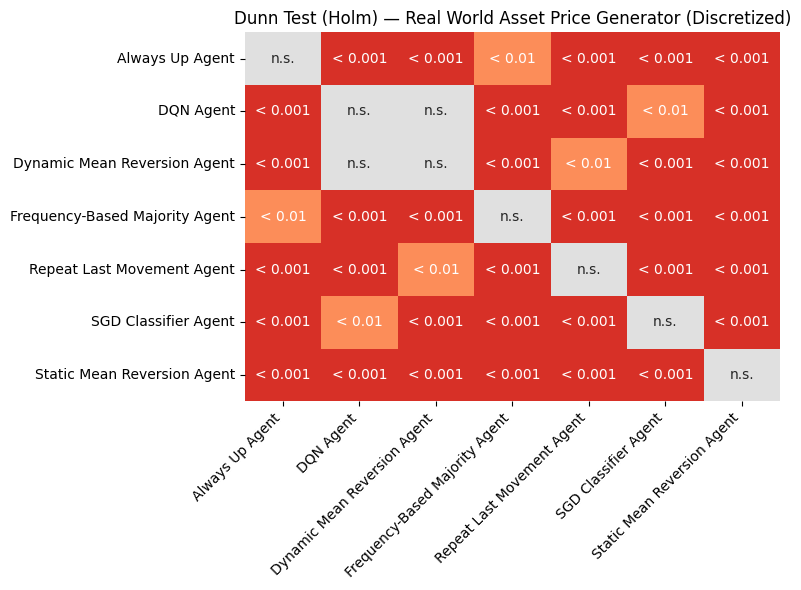

In [ ]:


# Mapping categories to numeric values for plotting
pval_bins = {
    "< 0.001": 3,
    "< 0.01": 2,
    "< 0.05": 1,
    "n.s.": 0
}

# Color palette for the bins
palette = {
    3: "#d73027",  # strong red
    2: "#fc8d59",  # light red
    1: "#fee090",  # yellow
    0: "#e0e0e0"   # gray
}

def discretize_pval_num(p):
    if p < 0.001:
        return 3
    elif p < 0.01:
        return 2
    elif p < 0.05:
        return 1
    else:
        return 0

def discretize_pval_label(p):
    if p < 0.001:
        return "< 0.001"
    elif p < 0.01:
        return "< 0.01"
    elif p < 0.05:
        return "< 0.05"
    else:
        return "n.s."

for generator in df["generator"].unique():
    subset = df[df["generator"] == generator]
    dunn = sp.posthoc_dunn(subset, val_col='final_cumulative_reward', group_col='agent', p_adjust='holm')
    
    dunn_discrete = dunn.applymap(discretize_pval_num)
    dunn_labels = dunn.applymap(discretize_pval_label)

    plt.figure(figsize=(8, 6))
    sns.heatmap(dunn_discrete, annot=dunn_labels, fmt='', cmap=[palette[k] for k in sorted(palette.keys())], cbar=False)
    plt.title(f"Dunn Test (Holm) — {generator} (Discretized)")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# 5 Convergence Analysis

 redo this section as currently I look at reward development and not actual convergence to maximum reward over runs

In [ ]:
convergence_df

,agent,generator,run_id,step,cumulative_reward
0,Always Up Agent,Constant Generator,1,1,-1.0
1,Always Up Agent,Constant Generator,1,2,-2.0
2,Always Up Agent,Constant Generator,1,3,-3.0
3,Always Up Agent,Constant Generator,1,4,-4.0
4,Always Up Agent,Constant Generator,1,5,-5.0
...,...,...,...,...,...
55999995,Static Mean Reversion Agent,Real World Asset Price Generator,100,9996,-640.0
55999996,Static Mean Reversion Agent,Real World Asset Price Generator,100,9997,-639.0
55999997,Static Mean Reversion Agent,Real World Asset Price Generator,100,9998,-638.0
55999998,Static Mean Reversion Agent,Real World Asset Price Generator,100,9999,-639.0


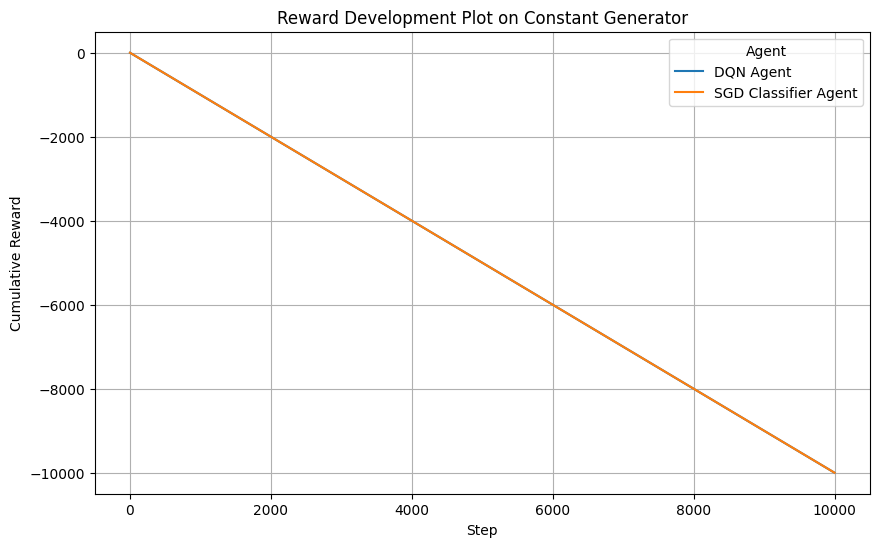

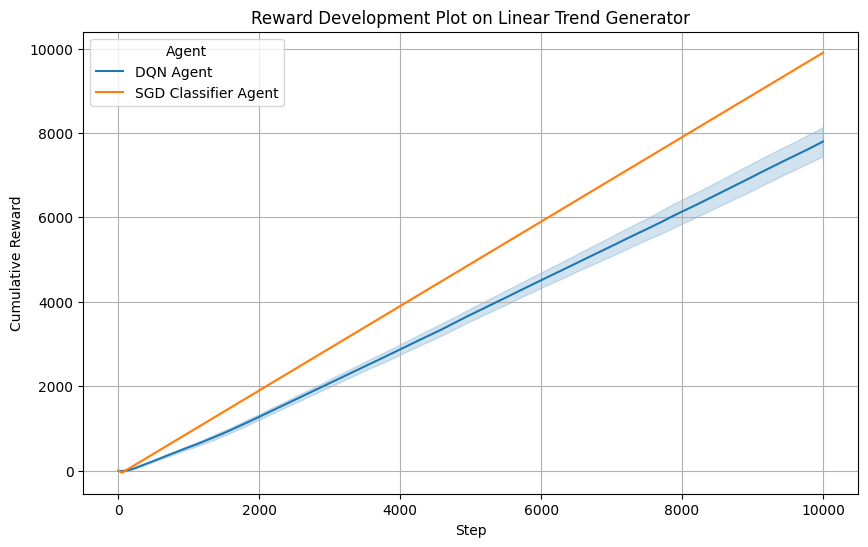

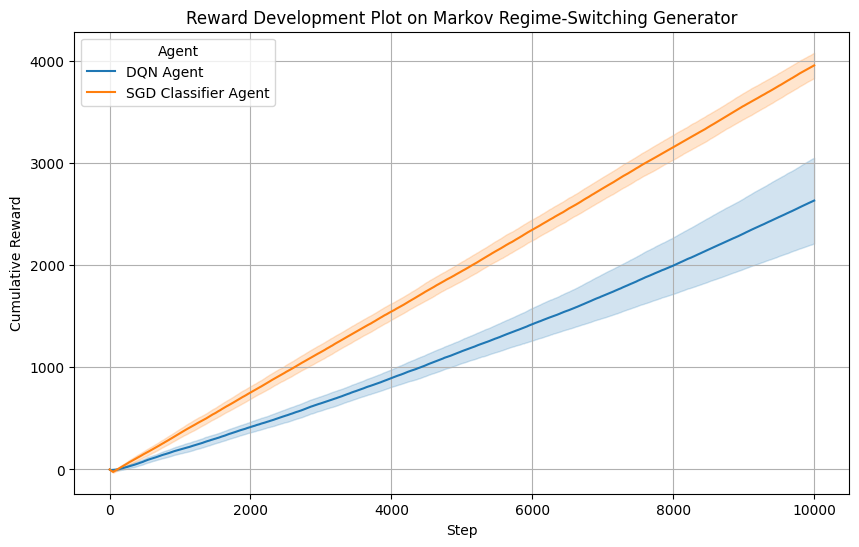

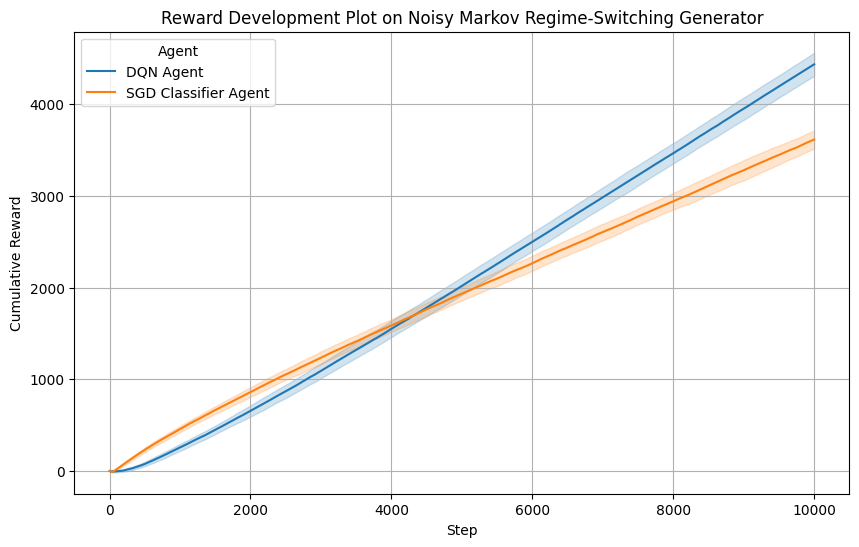

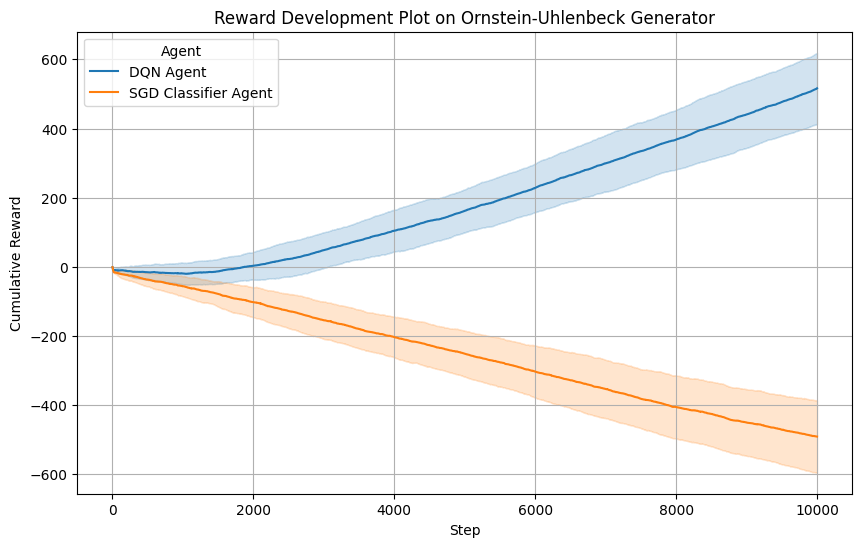

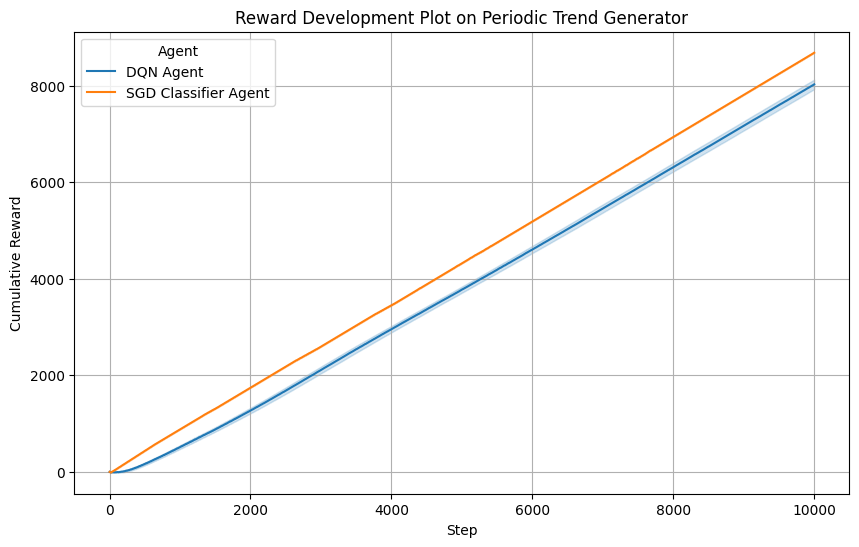

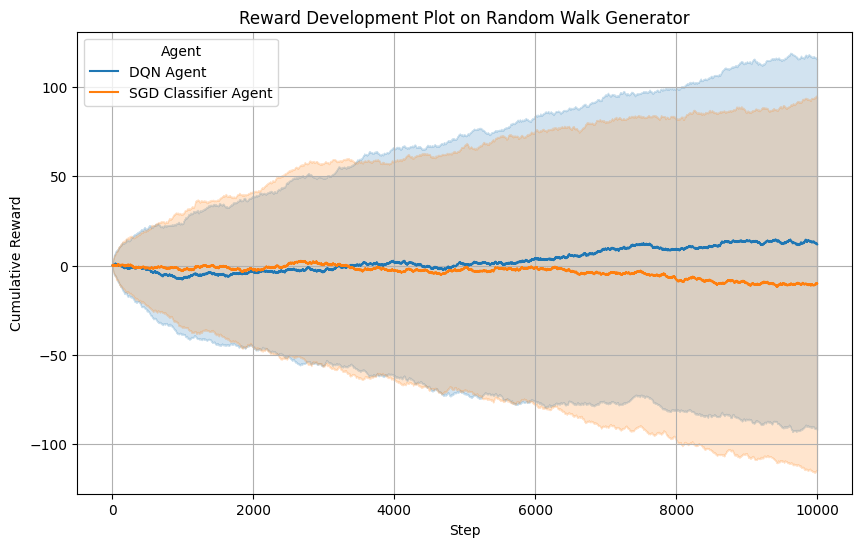

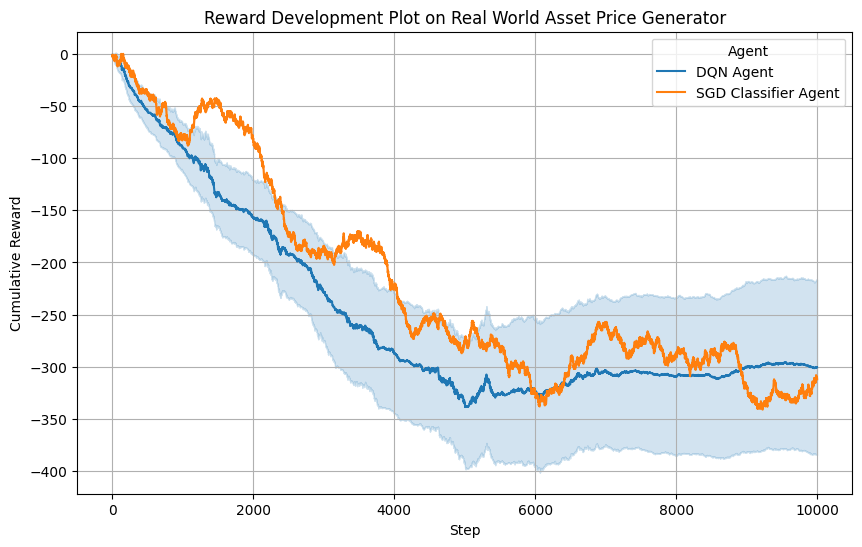

In [ ]:

# Assuming your data is in df_convergence
# Filter for DQN and SGD agents only
agents_of_interest = ["DQN Agent", "SGD Classifier Agent"]
df_plot = convergence_df[convergence_df["agent"].isin(agents_of_interest)]

# Loop over generators
for generator in df_plot["generator"].unique():
    plt.figure(figsize=(10, 6))
    subset = df_plot[df_plot["generator"] == generator]

    sns.lineplot(
        data=subset,
        x="step",
        y="cumulative_reward",
        hue="agent",
        errorbar="sd",  # Shaded area = standard deviation across runs
        estimator="mean"
    )

    plt.title(f"Reward Development Plot on {generator}")
    plt.xlabel("Step")
    plt.ylabel("Cumulative Reward")
    plt.legend(title="Agent")
    plt.grid(True)
    plt.show()


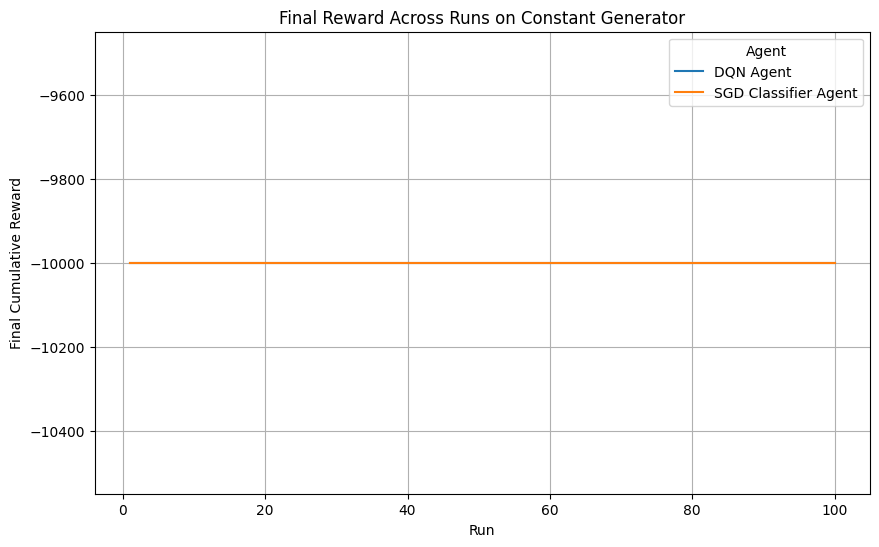

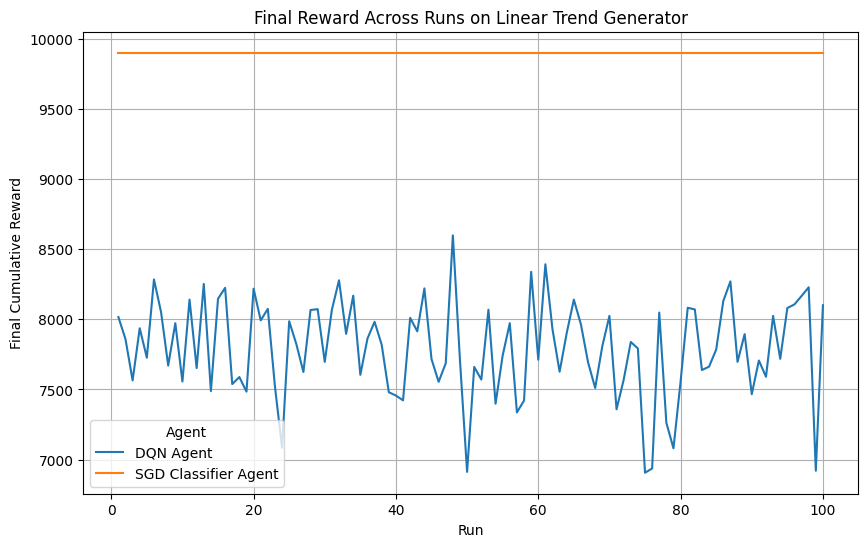

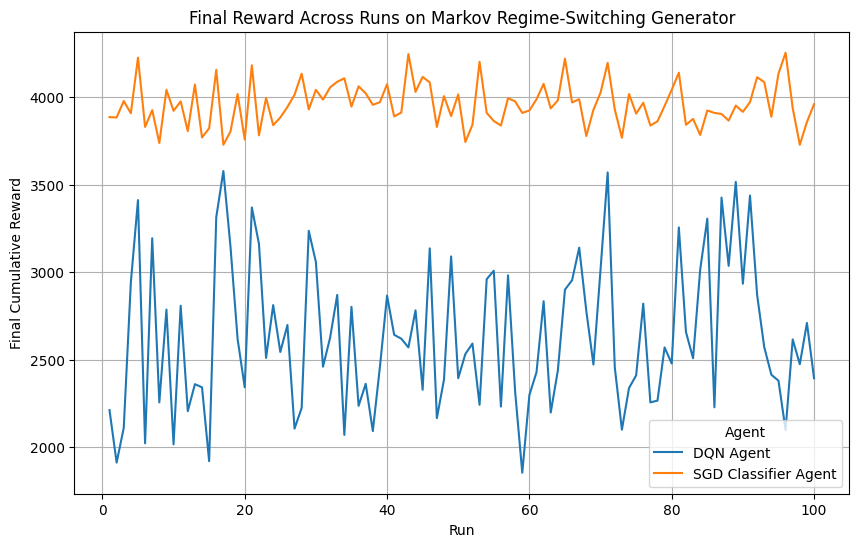

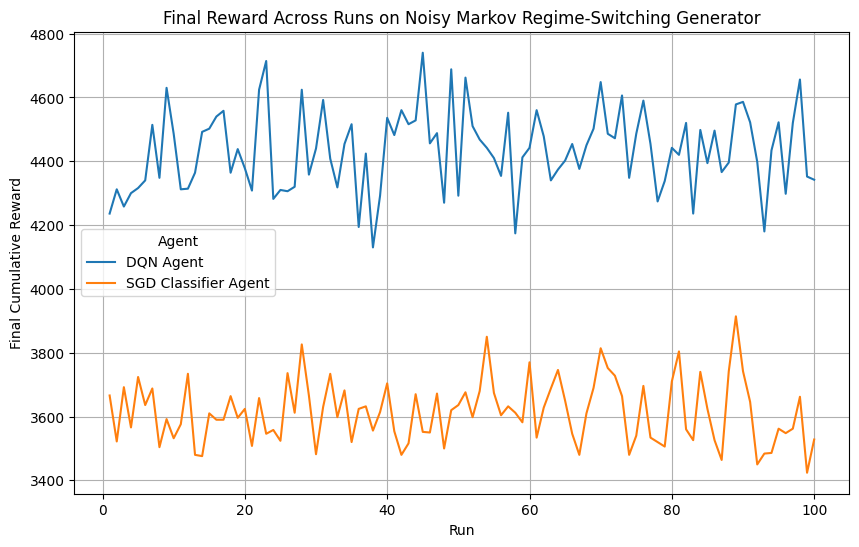

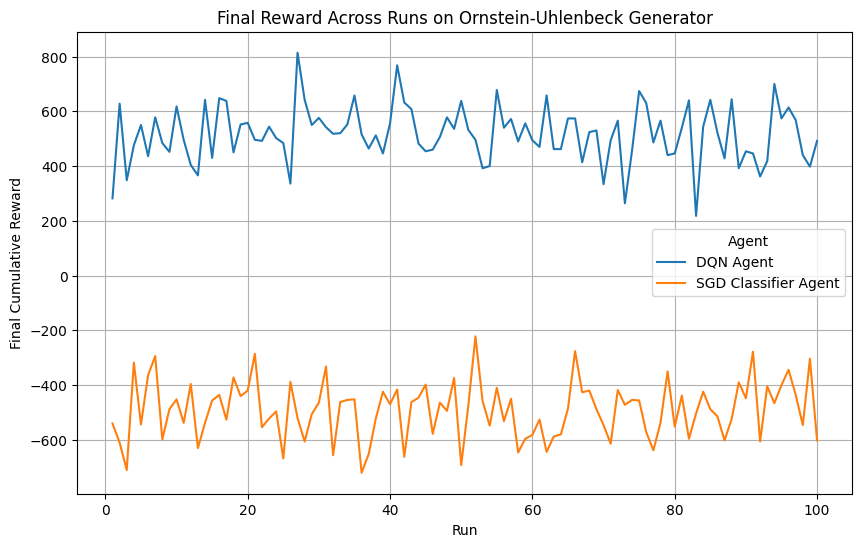

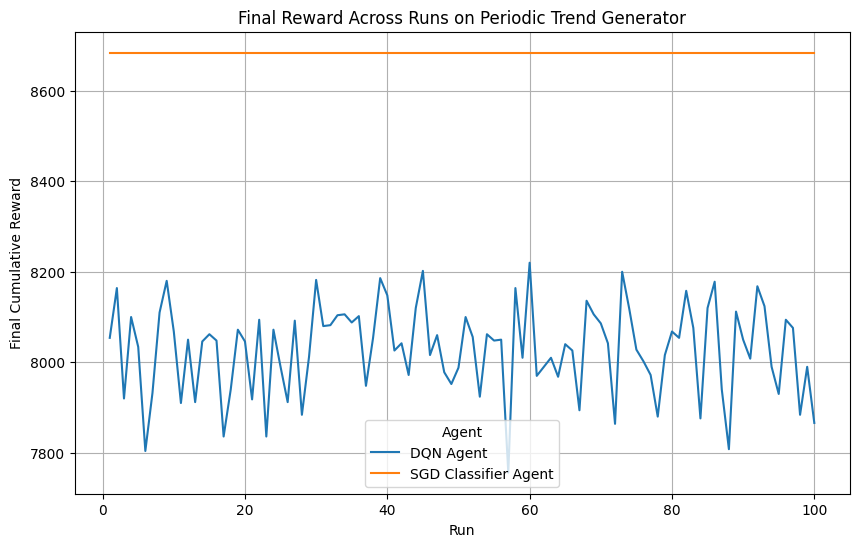

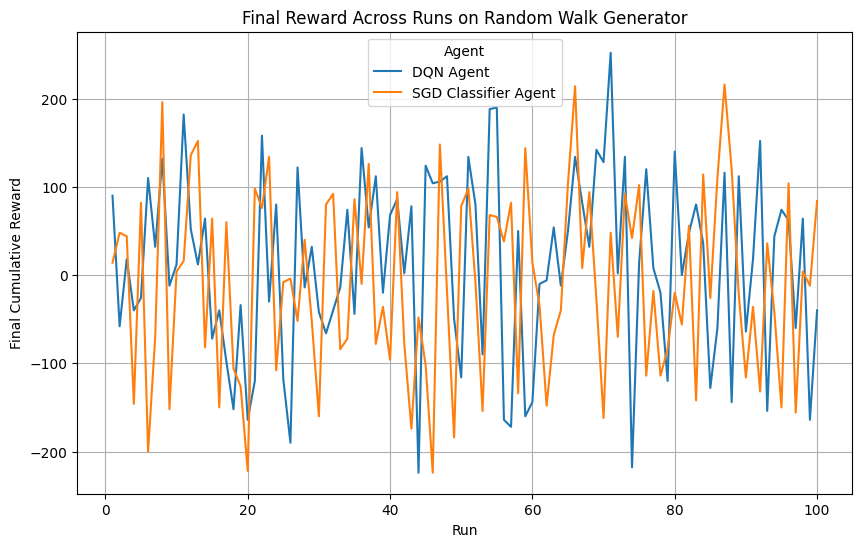

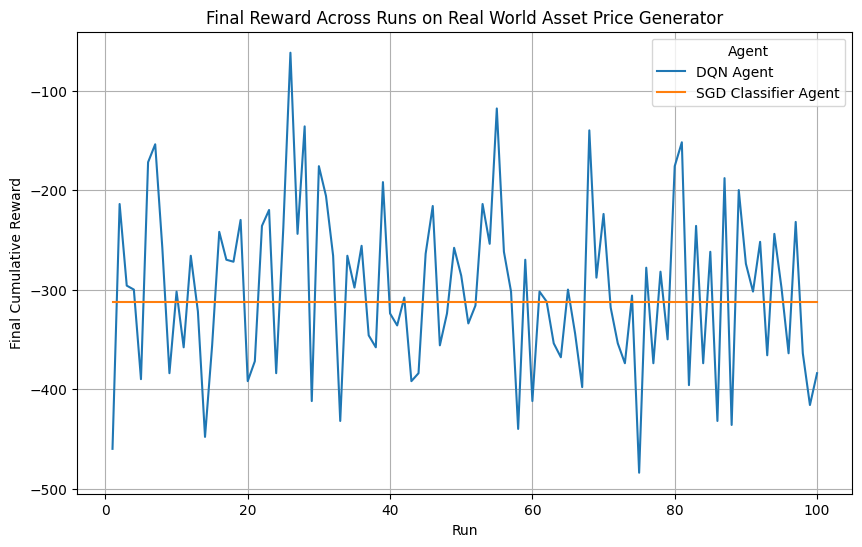

In [ ]:
# plot final reward across runs by filtering rows with max step value 

max_step = df_plot["step"].max()
df_plot = df_plot[df_plot["step"] == max_step]

# For each generator, create line plot the final rewards by agent across runs
for generator in df_plot["generator"].unique():
    plt.figure(figsize=(10, 6))
    subset = df_plot[df_plot["generator"] == generator]

    sns.lineplot(
        data=subset,
        x="run_id",
        y="cumulative_reward",
        hue="agent"
        )

    plt.title(f"Final Reward Across Runs on {generator}")
    plt.xlabel("Run")
    plt.ylabel("Final Cumulative Reward")
    plt.legend(title="Agent")
    plt.grid(True)
    plt.show()

    
